In [ ]:
# ============================================================
# CÉLULA BASE — IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# ============================================================

import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection    import train_test_split, StratifiedKFold
from sklearn.preprocessing      import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics            import (accuracy_score, balanced_accuracy_score,
                                        f1_score, recall_score, precision_score,
                                        classification_report, confusion_matrix,
                                        roc_auc_score, average_precision_score,
                                        precision_recall_curve, roc_curve)
from sklearn.dummy              import DummyClassifier
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Ruta base del proyecto en Drive
PROJECT_PATH = '/content/drive/MyDrive/inteligencia_artificial_colab'

print("=" * 55)
print("  THE GOOD DOCTOR IA — NOTEBOOK v2")
print("  XGBoost Stage 1 + MLP Stage 2")
print("=" * 55)
print(f"\n  XGBoost version : {xgb.__version__}")
print(f"  TensorFlow      : {tf.__version__}")
print(f"  Random State    : {RANDOM_STATE}")
print("\n  Lecciones del Notebook v1:")
print("  → MLP puro (v1-v6): precisión Sepsis nunca superó el 7%")
print("  → AUC Stage 1 MLP máximo alcanzado: 0.57 (casi azar)")
print("  → Causa raíz: redes neuronales no aprenden reglas")
print("    clínicas discontinuas con estas features")
print("  → Solución: XGBoost aprende fronteras tipo reglas")
print("    (if MAP<65 AND creatinina>2.0 → Sepsis)")
print("  ✅ Entorno configurado.")

  THE GOOD DOCTOR IA — NOTEBOOK v2
  XGBoost Stage 1 + MLP Stage 2

  XGBoost version : 3.2.0
  TensorFlow      : 2.20.0
  Random State    : 42

  Lecciones del Notebook v1:
  → MLP puro (v1-v6): precisión Sepsis nunca superó el 7%
  → AUC Stage 1 MLP máximo alcanzado: 0.57 (casi azar)
  → Causa raíz: redes neuronales no aprenden reglas
    clínicas discontinuas con estas features
  → Solución: XGBoost aprende fronteras tipo reglas
    (if MAP<65 AND creatinina>2.0 → Sepsis)
  ✅ Entorno configurado.


In [ ]:
# ============================================================
# CELDA 2 — CARGA ÚNICA DEL DATASET
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = (f'{PROJECT_PATH}/clinical_dataset/'
                'clinical_dataset.csv')

df = pd.read_csv(DATASET_PATH, low_memory=False)

print("=" * 55)
print("  DATASET CARGADO — NOTEBOOK v2")
print("=" * 55)
print(f"\n  Filas (pacientes)  : {df.shape[0]:,}")
print(f"  Columnas (features): {df.shape[1]}")

print("\n  Primeras 5 filas:")
display(df.head())

print("\n  Tipos de datos:")
display(df.dtypes.to_frame(name='Tipo'))

# ─── Línea de base heredada del Notebook v1 ───
print("\n" + "=" * 55)
print("  LÍNEA DE BASE HEREDADA DEL NOTEBOOK v1")
print("  (Mejor resultado alcanzado con MLP puro)")
print("=" * 55)
BASELINE_V1 = {
    'Modelo'           : 'MLP v5 Two-Stage (mejor del NB v1)',
    'Accuracy'         : 0.0887,
    'Balanced Acc.'    : 0.2554,
    'F1 Macro'         : 0.0552,
    'Recall Sepsis'    : 0.9688,
    'Precisión Sepsis' : 0.0654,
    'F1 Sepsis'        : 0.1225,
    'FN Sepsis'        : 3,
    'FP Sepsis'        : 1329
}
print("\n  El Notebook v2 debe superar estas métricas en EQUILIBRIO:")
print(f"  Precisión Sepsis actual : {BASELINE_V1['Precisión Sepsis']} (objetivo: > 0.20)")
print(f"  F1 Sepsis actual        : {BASELINE_V1['F1 Sepsis']} (objetivo: > 0.35)")
print(f"  F1 Macro actual         : {BASELINE_V1['F1 Macro']} (objetivo: > 0.50)")

Mounted at /content/drive
  DATASET CARGADO — NOTEBOOK v2

  Filas (pacientes)  : 10,000
  Columnas (features): 14

  Primeras 5 filas:


,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,diagnosis,readmission_30d,mortality
0,1001,63,Male,24.1,131.0,81.0,136.2,210.3,1.04,0,0,Sepsis,0,0
1,1002,52,Male,20.8,118.0,91.0,136.5,207.9,1.49,0,1,Normal,0,0
2,1003,66,Male,30.0,144.0,73.0,100.0,179.5,1.15,0,0,Normal,0,0
3,1004,82,Male,16.8,112.0,76.0,117.3,228.3,0.59,0,0,Heart Failure,0,0
4,1005,50,Female,25.4,102.0,65.0,128.0,150.7,1.38,0,0,Normal,0,0



  Tipos de datos:


,Tipo
patient_id,int64
age,int64
sex,object
bmi,float64
systolic_bp,float64
diastolic_bp,float64
glucose,float64
cholesterol,float64
creatinine,float64
diabetes,int64



  LÍNEA DE BASE HEREDADA DEL NOTEBOOK v1
  (Mejor resultado alcanzado con MLP puro)

  El Notebook v2 debe superar estas métricas en EQUILIBRIO:
  Precisión Sepsis actual : 0.0654 (objetivo: > 0.20)
  F1 Sepsis actual        : 0.1225 (objetivo: > 0.35)
  F1 Macro actual         : 0.0552 (objetivo: > 0.50)


In [ ]:
# ============================================================
# CELDA 3 — IDENTIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================

TARGET_COLUMN = 'diagnosis'

assert TARGET_COLUMN in df.columns, \
    f"ERROR: Columna '{TARGET_COLUMN}' no encontrada."

print("=" * 55)
print(f"  VARIABLE OBJETIVO: '{TARGET_COLUMN}'")
print("=" * 55)

class_counts = df[TARGET_COLUMN].value_counts()
total        = len(df)

print(f"\n  Clases únicas detectadas: {df[TARGET_COLUMN].nunique()}\n")
for cls, count in class_counts.items():
    pct = count / total * 100
    print(f"  • {cls:<25} → {count:>6,} pacientes ({pct:.1f}%)")

print(f"\n  Tipo de dato: {df[TARGET_COLUMN].dtype}")
print(f"\n  📌 NOTA PARA XGBoost:")
print(f"  → Stage 1: problema BINARIO (Sepsis=1 vs No-Sepsis=0)")
print(f"  → Stage 2: problema 3-CLASES (HF, Normal, Pneumonia)")
print(f"  → XGBoost acepta enteros directamente sin one-hot encoding")

  VARIABLE OBJETIVO: 'diagnosis'

  Clases únicas detectadas: 4

  • Normal                    →  5,590 pacientes (55.9%)
  • Pneumonia                 →  2,005 pacientes (20.1%)
  • Heart Failure             →  1,763 pacientes (17.6%)
  • Sepsis                    →    642 pacientes (6.4%)

  Tipo de dato: object

  📌 NOTA PARA XGBoost:
  → Stage 1: problema BINARIO (Sepsis=1 vs No-Sepsis=0)
  → Stage 2: problema 3-CLASES (HF, Normal, Pneumonia)
  → XGBoost acepta enteros directamente sin one-hot encoding


  AUDITORÍA DE CALIDAD DE DATOS

  ✅ Sin valores nulos.

  Duplicados: 0 ✅

  Estadísticas descriptivas:


,patient_id,age,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,6000.50,54.30,27.02,124.81,80.34,106.01,190.89,1.00,0.12,0.30,0.14,0.03
std,2886.90,17.64,5.83,17.65,11.39,23.38,34.33,0.29,0.32,0.46,0.35,0.16
min,1001.00,0.00,15.00,90.00,60.00,70.00,120.00,0.50,0.00,0.00,0.00,0.00
25%,3500.75,42.00,22.90,112.00,72.00,88.10,166.78,0.79,0.00,0.00,0.00,0.00
50%,6000.50,54.00,27.00,125.00,80.00,105.30,190.85,1.00,0.00,0.00,0.00,0.00
75%,8500.25,67.00,31.00,137.00,88.00,122.10,214.40,1.20,0.00,1.00,0.00,0.00
max,11000.00,90.00,50.00,180.00,110.00,198.60,300.00,2.13,1.00,1.00,1.00,1.00


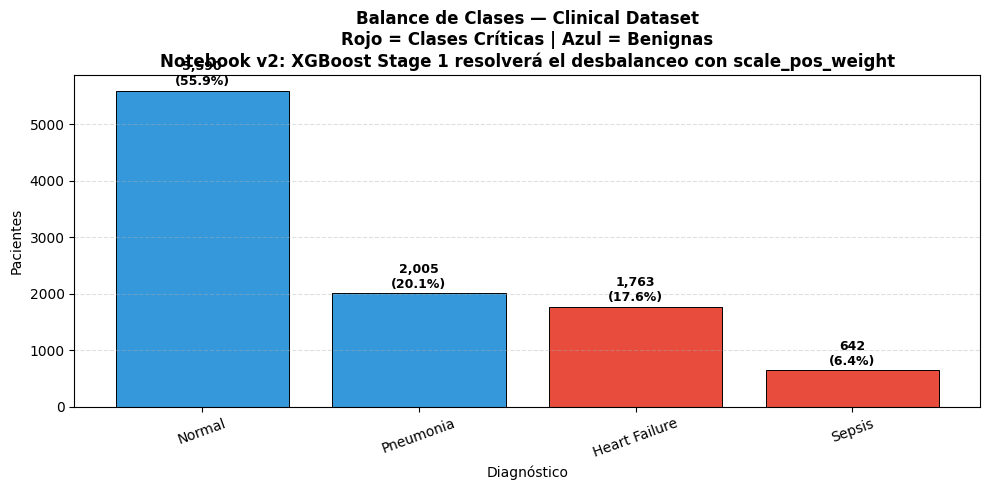


  [OK] Gráfico guardado.


In [ ]:
# ============================================================
# CELDA 4 — REVISIÓN DE CALIDAD DE DATOS
# ============================================================

print("=" * 55)
print("  AUDITORÍA DE CALIDAD DE DATOS")
print("=" * 55)

# Nulos
nulls    = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df  = pd.DataFrame({'Nulos': nulls, '%': null_pct})
null_df  = null_df[null_df['Nulos'] > 0]
if null_df.empty:
    print("\n  ✅ Sin valores nulos.")
else:
    print("\n  ⚠️  Valores nulos detectados:")
    display(null_df)

# Duplicados
n_dup = df.duplicated().sum()
print(f"\n  Duplicados: {n_dup} {'✅' if n_dup == 0 else '⚠️ '}")

# Estadísticas
print("\n  Estadísticas descriptivas:")
display(df.describe().round(2))

# ─── Gráfico de Balance de Clases ───
fig, ax = plt.subplots(figsize=(10, 5))

counts_sorted = df[TARGET_COLUMN].value_counts().sort_values(ascending=False)
colors = ['#e74c3c' if any(k in c.lower() for k in ['sepsis', 'heart', 'failure'])
          else '#3498db' for c in counts_sorted.index]

bars = ax.bar(counts_sorted.index, counts_sorted.values,
              color=colors, edgecolor='black', linewidth=0.7)

total_ = counts_sorted.sum()
for bar, val in zip(bars, counts_sorted.values):
    pct = val / total_ * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_*0.005,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Balance de Clases — Clinical Dataset\n'
             'Rojo = Clases Críticas | Azul = Benignas\n'
             'Notebook v2: XGBoost Stage 1 resolverá el desbalanceo con scale_pos_weight',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Diagnóstico'); ax.set_ylabel('Pacientes')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/balance_clases_nb2.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  [OK] Gráfico guardado.")

In [ ]:
# ============================================================
# CELDA 5 — LIMPIEZA + FEATURE ENGINEERING + DEFINICIÓN X/y
# ============================================================

# Eliminar duplicados
n_before = len(df)
df = df.drop_duplicates()
if n_before != len(df):
    print(f"  [LIMPIEZA] {n_before - len(df)} duplicados eliminados.")

# ─── Feature Engineering v6 (fórmulas corregidas) ───
def add_clinical_features(df_input):
    """
    Features clínicas derivadas — versión corregida del Notebook v1 v6.
    Todas validadas con std en rango normal (no hay std=3235 como en v5).
    """
    df_out = df_input.copy()

    # 1. Presión de pulso: diferencia sistólica - diastólica
    #    Baja en shock, alta en vasodilatación séptica
    df_out['pulse_pressure'] = df_out['systolic_bp'] - df_out['diastolic_bp']

    # 2. MAP aproximado — criterio Sepsis-3 (MAP<65 = shock séptico)
    df_out['map_approx'] = (df_out['systolic_bp'] + 2*df_out['diastolic_bp']) / 3

    # 3. Log-ratio creatinina/glucosa — versión estable (std~0.18 vs 3235 en v5)
    df_out['log_creatinine_glucose'] = (
        np.log1p(df_out['creatinine']) -
        np.log1p(df_out['glucose'] / 100)
    )

    # 4. Score de riesgo orgánico — umbrales estrictos Sepsis-3
    #    MAP<65, creatinina>2.0, glucosa>160 sin diabetes
    map_val  = (df_out['systolic_bp'] + 2*df_out['diastolic_bp']) / 3
    df_out['organ_risk_score'] = (
        (map_val < 65).astype(int) +
        (df_out['creatinine'] > 2.0).astype(int) +
        ((df_out['glucose'] > 160) & (df_out['diabetes'] == 0)).astype(int)
    )
    return df_out

df = add_clinical_features(df)

# ─── Codificar sex (XGBoost también lo necesita numérico) ───
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])
print(f"  [LabelEncoder] sex: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

# ─── Definir features y target ───
NUMERIC_FEATURES  = ['age', 'bmi', 'systolic_bp', 'diastolic_bp',
                     'glucose', 'cholesterol', 'creatinine']
BINARY_FEATURES   = ['sex', 'diabetes', 'hypertension']
DERIVED_FEATURES  = ['pulse_pressure', 'map_approx',
                     'log_creatinine_glucose', 'organ_risk_score']
ALL_FEATURES      = NUMERIC_FEATURES + BINARY_FEATURES + DERIVED_FEATURES  # 14 features

X = df[ALL_FEATURES].copy()
y = df[TARGET_COLUMN].copy()

# Validar features derivadas
print("\n  Validación de features derivadas:")
for feat in DERIVED_FEATURES:
    std_ = X[feat].std()
    flag = "✅" if 0.05 < std_ < 50 else "❌"
    print(f"  {feat:<30}: std={std_:.3f} {flag}")

print(f"\n  X shape : {X.shape}  (14 features = 10 originales + 4 derivadas)")
print(f"  y shape : {y.shape}")
print(f"\n  📌 NOTA XGBOOST: No aplicaremos StandardScaler.")
print(f"     Los árboles son invariantes a la escala de las features.")

  [LabelEncoder] sex: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

  Validación de features derivadas:
  pulse_pressure                : std=20.891 ✅
  map_approx                    : std=9.660 ✅
  log_creatinine_glucose        : std=0.182 ✅
  organ_risk_score              : std=0.115 ✅

  X shape : (10000, 14)  (14 features = 10 originales + 4 derivadas)
  y shape : (10000,)

  📌 NOTA XGBOOST: No aplicaremos StandardScaler.
     Los árboles son invariantes a la escala de las features.


In [ ]:
# ============================================================
# CELDA 6 — DIVISIÓN TRAIN / VALIDATION / TEST
# ============================================================

# Paso 1: Separar 15% para TEST
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y
)

# Paso 2: Del 85% restante, ~17.6% para VAL (= 15% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85,
    random_state=RANDOM_STATE, stratify=y_temp
)

total = len(X)
print("=" * 58)
print("  DIVISIÓN DE DATOS — NOTEBOOK v2")
print("=" * 58)
print(f"\n  Total   : {total:,} (100%)")
print(f"  Train   : {len(X_train):,} ({len(X_train)/total*100:.1f}%)")
print(f"  Val     : {len(X_val):,} ({len(X_val)/total*100:.1f}%)")
print(f"  Test    : {len(X_test):,} ({len(X_test)/total*100:.1f}%)")

print("\n  Verificación de estratificación:")
for name, y_split in [("TRAIN", y_train), ("VAL", y_val), ("TEST", y_test)]:
    dist = (y_split.value_counts(normalize=True)*100).round(1)
    sepsis_pct = dist.get('Sepsis', dist.get(dist.index[0], 0))
    # Buscar dinámicamente Sepsis
    for cls in dist.index:
        if 'sepsis' in cls.lower():
            sepsis_pct = dist[cls]
    print(f"  [{name}] Sepsis: {sepsis_pct:.1f}%  "
          f"(Total clases: {dict(dist.items())})")

print(f"\n  📌 MISMO RANDOM_STATE={RANDOM_STATE} que Notebook v1")
print(f"     → Test set idéntico → comparación justa entre MLP y XGBoost")

  DIVISIÓN DE DATOS — NOTEBOOK v2

  Total   : 10,000 (100%)
  Train   : 7,000 (70.0%)
  Val     : 1,500 (15.0%)
  Test    : 1,500 (15.0%)

  Verificación de estratificación:
  [TRAIN] Sepsis: 6.4%  (Total clases: {'Normal': 55.9, 'Pneumonia': 20.0, 'Heart Failure': 17.6, 'Sepsis': 6.4})
  [VAL] Sepsis: 6.4%  (Total clases: {'Normal': 55.9, 'Pneumonia': 20.1, 'Heart Failure': 17.7, 'Sepsis': 6.4})
  [TEST] Sepsis: 6.4%  (Total clases: {'Normal': 55.9, 'Pneumonia': 20.1, 'Heart Failure': 17.6, 'Sepsis': 6.4})

  📌 MISMO RANDOM_STATE=42 que Notebook v1
     → Test set idéntico → comparación justa entre MLP y XGBoost


In [ ]:
# ============================================================
# CELDA 7 — PREPROCESAMIENTO DIFERENCIADO
# ============================================================

print("=" * 60)
print("  PREPROCESAMIENTO v2 — DIFERENCIADO POR MODELO")
print("=" * 60)

# ─── 7A: Versión XGBoost — SIN escalado ───
# Solo convertimos a arrays numpy; XGBoost no necesita más
X_train_xgb = X_train.values.astype(np.float32)
X_val_xgb   = X_val.values.astype(np.float32)
X_test_xgb  = X_test.values.astype(np.float32)

print(f"\n  Versión XGBoost (sin escalar):")
print(f"  X_train_xgb : {X_train_xgb.shape}")
print(f"  Rango age   : [{X_train_xgb[:,0].min():.0f}, {X_train_xgb[:,0].max():.0f}]")
print(f"  ✅ Sin StandardScaler — los árboles son escala-invariantes")

# ─── 7B: Versión MLP — CON escalado (para Stage 2) ───
# StandardScaler para features numéricas originales
scaler_std = StandardScaler()
X_train_mlp = X_train.copy()
X_val_mlp   = X_val.copy()
X_test_mlp  = X_test.copy()

X_train_mlp[NUMERIC_FEATURES] = scaler_std.fit_transform(X_train_mlp[NUMERIC_FEATURES])
X_val_mlp[NUMERIC_FEATURES]   = scaler_std.transform(X_val_mlp[NUMERIC_FEATURES])
X_test_mlp[NUMERIC_FEATURES]  = scaler_std.transform(X_test_mlp[NUMERIC_FEATURES])

# RobustScaler para features derivadas continuas
DERIVED_CONTINUOUS = ['pulse_pressure', 'map_approx', 'log_creatinine_glucose']
scaler_rob = RobustScaler()
X_train_mlp[DERIVED_CONTINUOUS] = scaler_rob.fit_transform(X_train_mlp[DERIVED_CONTINUOUS])
X_val_mlp[DERIVED_CONTINUOUS]   = scaler_rob.transform(X_val_mlp[DERIVED_CONTINUOUS])
X_test_mlp[DERIVED_CONTINUOUS]  = scaler_rob.transform(X_test_mlp[DERIVED_CONTINUOUS])

# organ_risk_score con StandardScaler
scaler_risk = StandardScaler()
X_train_mlp[['organ_risk_score']] = scaler_risk.fit_transform(X_train_mlp[['organ_risk_score']])
X_val_mlp[['organ_risk_score']]   = scaler_risk.transform(X_val_mlp[['organ_risk_score']])
X_test_mlp[['organ_risk_score']]  = scaler_risk.transform(X_test_mlp[['organ_risk_score']])

X_train_mlp_arr = X_train_mlp.values.astype(np.float32)
X_val_mlp_arr   = X_val_mlp.values.astype(np.float32)
X_test_mlp_arr  = X_test_mlp.values.astype(np.float32)

print(f"\n  Versión MLP (escalada — para Stage 2):")
print(f"  X_train_mlp : {X_train_mlp_arr.shape}")
print(f"  Rango age   : [{X_train_mlp_arr[:,0].min():.2f}, {X_train_mlp_arr[:,0].max():.2f}]")
print(f"  ✅ StdScaler (numéricas) + RobustScaler (derivadas)")

print(f"\n  Resumen:")
print(f"  → XGBoost Stage 1 usará : X_train_xgb (sin escalar)")
print(f"  → MLP Stage 2 usará     : X_train_mlp_arr (escalada)")

  PREPROCESAMIENTO v2 — DIFERENCIADO POR MODELO

  Versión XGBoost (sin escalar):
  X_train_xgb : (7000, 14)
  Rango age   : [0, 90]
  ✅ Sin StandardScaler — los árboles son escala-invariantes

  Versión MLP (escalada — para Stage 2):
  X_train_mlp : (7000, 14)
  Rango age   : [-3.09, 2.03]
  ✅ StdScaler (numéricas) + RobustScaler (derivadas)

  Resumen:
  → XGBoost Stage 1 usará : X_train_xgb (sin escalar)
  → MLP Stage 2 usará     : X_train_mlp_arr (escalada)


In [ ]:
# ============================================================
# CELDA 8 — CODIFICACIÓN DE CLASES
# ============================================================

# LabelEncoder para el target completo (4 clases)
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_val_enc   = le_target.transform(y_val)
y_test_enc  = le_target.transform(y_test)

NUM_CLASSES = len(le_target.classes_)
CLASS_NAMES = le_target.classes_.tolist()

print("=" * 55)
print("  CODIFICACIÓN DE CLASES")
print("=" * 55)
print(f"\n  Total clases: {NUM_CLASSES}")
print("\n  Mapeo Clase → Índice:")
for idx, cls in enumerate(le_target.classes_):
    n = (y_train_enc == idx).sum()
    print(f"    [{idx}] {cls:<25} → {n:,} en train ({n/len(y_train_enc)*100:.1f}%)")

# ─── Target binario para Stage 1 ───
# Se define aquí, se usa en celda 12
print(f"\n  Target Stage 1 (binario) → se construye en celda 12")
print(f"  Target Stage 2 (3 clases) → se construye en celda 18")
print(f"\n  CLASS_NAMES : {CLASS_NAMES}")

  CODIFICACIÓN DE CLASES

  Total clases: 4

  Mapeo Clase → Índice:
    [0] Heart Failure             → 1,234 en train (17.6%)
    [1] Normal                    → 3,913 en train (55.9%)
    [2] Pneumonia                 → 1,403 en train (20.0%)
    [3] Sepsis                    → 450 en train (6.4%)

  Target Stage 1 (binario) → se construye en celda 12
  Target Stage 2 (3 clases) → se construye en celda 18

  CLASS_NAMES : ['Heart Failure', 'Normal', 'Pneumonia', 'Sepsis']


In [ ]:
# ============================================================
# CELDA 9 — DEFINIR CLASE CRÍTICA
# ============================================================

CRITICAL_KEYWORDS = ['sepsis', 'heart failure', 'cardiac', 'stroke', 'acute']
CRITICAL_CLASS_NAME = None
CRITICAL_CLASS_IDX  = None

for keyword in CRITICAL_KEYWORDS:
    for idx, cls in enumerate(le_target.classes_):
        if keyword.lower() in cls.lower():
            CRITICAL_CLASS_NAME = cls
            CRITICAL_CLASS_IDX  = idx
            break
    if CRITICAL_CLASS_NAME:
        break

if CRITICAL_CLASS_NAME is None:
    raise ValueError("No se detectó clase crítica. Definir manualmente.")

n_critical = (y_train_enc == CRITICAL_CLASS_IDX).sum()
n_total    = len(y_train_enc)

print("=" * 55)
print("  CLASE CRÍTICA IDENTIFICADA")
print("=" * 55)
print(f"\n  Nombre : '{CRITICAL_CLASS_NAME}'")
print(f"  Índice : {CRITICAL_CLASS_IDX}")
print(f"  Train  : {n_critical:,} / {n_total:,} ({n_critical/n_total*100:.2f}%)")

print(f"\n  Implicaciones para el Notebook v2:")
print(f"  → Stage 1 XGBoost: clase positiva = {CRITICAL_CLASS_IDX}")
print(f"  → scale_pos_weight = {(n_total-n_critical)/n_critical:.2f}")
print(f"     (relación No-Sepsis / Sepsis en training)")
print(f"  → Minimizar FN de '{CRITICAL_CLASS_NAME}' es la prioridad máxima")

# scale_pos_weight para XGBoost Stage 1
SCALE_POS_WEIGHT = (n_total - n_critical) / n_critical
print(f"\n  SCALE_POS_WEIGHT calculado: {SCALE_POS_WEIGHT:.2f}")

  CLASE CRÍTICA IDENTIFICADA

  Nombre : 'Sepsis'
  Índice : 3
  Train  : 450 / 7,000 (6.43%)

  Implicaciones para el Notebook v2:
  → Stage 1 XGBoost: clase positiva = 3
  → scale_pos_weight = 14.56
     (relación No-Sepsis / Sepsis en training)
  → Minimizar FN de 'Sepsis' es la prioridad máxima

  SCALE_POS_WEIGHT calculado: 14.56


In [ ]:
# ============================================================
# CELDA 10 — BASELINE PROFESIONAL
# ============================================================

print("=" * 65)
print("  BASELINE — MODELOS DE REFERENCIA")
print("=" * 65)

baseline_results = {}

# ─── 10A: DummyClassifier ───
for strategy in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train_xgb, y_train_enc)
    y_pred_d   = dummy.predict(X_val_xgb)
    acc_d      = accuracy_score(y_val_enc, y_pred_d)
    f1_mac_d   = f1_score(y_val_enc, y_pred_d, average='macro', zero_division=0)
    rec_crit_d = recall_score(y_val_enc, y_pred_d,
                              labels=[CRITICAL_CLASS_IDX],
                              average='macro', zero_division=0)
    baseline_results[f'Dummy ({strategy})'] = {
        'Accuracy': round(acc_d, 4),
        'F1 Macro': round(f1_mac_d, 4),
        f'Recall {CRITICAL_CLASS_NAME}': round(rec_crit_d, 4)
    }
    print(f"\n  Dummy ({strategy}):")
    print(f"    Accuracy : {acc_d:.4f} | F1 Macro: {f1_mac_d:.4f} | "
          f"Recall Sepsis: {rec_crit_d:.4f}")

# ─── 10B: XGBoost por defecto (4 clases, sin tuning) ───
print(f"\n  XGBoost base (hiperparámetros por defecto, 4 clases):")
xgb_base = xgb.XGBClassifier(
    objective       = 'multi:softprob',
    num_class       = NUM_CLASSES,
    random_state    = RANDOM_STATE,
    eval_metric     = 'mlogloss',
    use_label_encoder = False,
    verbosity       = 0
)
xgb_base.fit(X_train_xgb, y_train_enc,
             eval_set=[(X_val_xgb, y_val_enc)], verbose=False)

y_pred_xgb_base = xgb_base.predict(X_val_xgb)
acc_xb   = accuracy_score(y_val_enc, y_pred_xgb_base)
f1_xb    = f1_score(y_val_enc, y_pred_xgb_base, average='macro', zero_division=0)
rec_xb   = recall_score(y_val_enc, y_pred_xgb_base,
                        labels=[CRITICAL_CLASS_IDX],
                        average='macro', zero_division=0)
pre_xb   = precision_score(y_val_enc, y_pred_xgb_base,
                           labels=[CRITICAL_CLASS_IDX],
                           average='macro', zero_division=0)

baseline_results['XGBoost base (4 clases, sin tuning)'] = {
    'Accuracy': round(acc_xb, 4),
    'F1 Macro': round(f1_xb, 4),
    f'Recall {CRITICAL_CLASS_NAME}': round(rec_xb, 4),
    f'Precisión {CRITICAL_CLASS_NAME}': round(pre_xb, 4)
}
print(f"    Accuracy  : {acc_xb:.4f}")
print(f"    F1 Macro  : {f1_xb:.4f}")
print(f"    Recall Sep: {rec_xb:.4f}")
print(f"    Prec Sep  : {pre_xb:.4f}")
print(f"\n  📌 Si XGBoost base supera al mejor MLP (F1 Sep=0.1225)")
print(f"     en val, el cambio de estrategia está justificado.")

  BASELINE — MODELOS DE REFERENCIA

  Dummy (most_frequent):
    Accuracy : 0.5587 | F1 Macro: 0.1792 | Recall Sepsis: 0.0000

  Dummy (stratified):
    Accuracy : 0.3867 | F1 Macro: 0.2487 | Recall Sepsis: 0.0625

  XGBoost base (hiperparámetros por defecto, 4 clases):
    Accuracy  : 0.5247
    F1 Macro  : 0.2201
    Recall Sep: 0.0208
    Prec Sep  : 0.2222

  📌 Si XGBoost base supera al mejor MLP (F1 Sep=0.1225)
     en val, el cambio de estrategia está justificado.


In [ ]:
# ============================================================
# CELDA 11 — HISTORIAL NOTEBOOK v1 (REFERENCIA)
# ============================================================

historial_nb1 = pd.DataFrame([
    {'Versión': 'MLP v1 (CE auto)',       'Accuracy': 0.2293, 'Balanced Acc': 0.2520,
     'F1 Macro': 0.2109, 'Recall Sep': 0.2396, 'Prec Sep': None,  'FN': 73},
    {'Versión': 'MLP v2 (CE manual)',     'Accuracy': 0.4560, 'Balanced Acc': 0.2533,
     'F1 Macro': 0.2448, 'Recall Sep': 0.0104, 'Prec Sep': None,  'FN': 95},
    {'Versión': 'MLP v3 (FL+SMOTE 20%)', 'Accuracy': 0.1333, 'Balanced Acc': 0.2443,
     'F1 Macro': 0.1457, 'Recall Sep': 0.4792, 'Prec Sep': 0.0600,'FN': 50},
    {'Versión': 'MLP v4 (FL calibrada)', 'Accuracy': 0.3953, 'Balanced Acc': 0.2423,
     'F1 Macro': 0.2046, 'Recall Sep': 0.2396, 'Prec Sep': 0.0562,'FN': 73},
    {'Versión': 'MLP v5 (2-Stage FE roto)','Accuracy':0.0887,'Balanced Acc': 0.2554,
     'F1 Macro': 0.0552, 'Recall Sep': 0.9688, 'Prec Sep': 0.0654,'FN': 3},
    {'Versión': 'MLP v6 (2-Stage FE OK)', 'Accuracy': 0.1453, 'Balanced Acc': 0.2554,
     'F1 Macro': 0.1069, 'Recall Sep': 0.8333, 'Prec Sep': 0.0648,'FN': 16},
]).set_index('Versión')

print("=" * 80)
print("  HISTORIAL COMPLETO — NOTEBOOK v1 (6 versiones MLP)")
print("=" * 80)
display(historial_nb1.style
        .highlight_max(subset=['Accuracy','F1 Macro','Recall Sep','Prec Sep'],
                       color='#d4edda')
        .highlight_min(subset=['FN'], color='#d4edda')
        .format("{:.4f}", na_rep="N/A",
                subset=historial_nb1.select_dtypes(float).columns)
)
print(f"\n  CONCLUSIÓN DEL NOTEBOOK v1:")
print(f"  → Precisión de Sepsis: bloqueada en 6.5% durante v3-v6")
print(f"  → AUC Stage 1 MLP: nunca superó 0.57 (azar=0.50)")
print(f"  → Causa: MLP no aprende fronteras tipo reglas clínicas")
print(f"\n  OBJETIVO DEL NOTEBOOK v2:")
print(f"  → XGBoost Stage 1: AUC > 0.80, Precisión Sep > 0.20")
print(f"  → F1 Macro general > 0.50")

  HISTORIAL COMPLETO — NOTEBOOK v1 (6 versiones MLP)


,Accuracy,Balanced Acc,F1 Macro,Recall Sep,Prec Sep,FN
Versión,,,,,,
MLP v1 (CE auto),0.2293,0.2520,0.2109,0.2396,N/A,73
MLP v2 (CE manual),0.4560,0.2533,0.2448,0.0104,N/A,95
MLP v3 (FL+SMOTE 20%),0.1333,0.2443,0.1457,0.4792,0.0600,50
MLP v4 (FL calibrada),0.3953,0.2423,0.2046,0.2396,0.0562,73
MLP v5 (2-Stage FE roto),0.0887,0.2554,0.0552,0.9688,0.0654,3
MLP v6 (2-Stage FE OK),0.1453,0.2554,0.1069,0.8333,0.0648,16



  CONCLUSIÓN DEL NOTEBOOK v1:
  → Precisión de Sepsis: bloqueada en 6.5% durante v3-v6
  → AUC Stage 1 MLP: nunca superó 0.57 (azar=0.50)
  → Causa: MLP no aprende fronteras tipo reglas clínicas

  OBJETIVO DEL NOTEBOOK v2:
  → XGBoost Stage 1: AUC > 0.80, Precisión Sep > 0.20
  → F1 Macro general > 0.50


In [ ]:
# ============================================================
# CELDA 12 — STAGE 1: XGBOOST BINARIO
# ============================================================

print("=" * 65)
print("  STAGE 1 — XGBoost Binario: Sepsis vs No-Sepsis")
print("=" * 65)

# Targets binarios
y_train_s1 = (y_train_enc == CRITICAL_CLASS_IDX).astype(int)
y_val_s1   = (y_val_enc   == CRITICAL_CLASS_IDX).astype(int)
y_test_s1  = (y_test_enc  == CRITICAL_CLASS_IDX).astype(int)

print(f"\n  Target binario Stage 1:")
print(f"  Train: {y_train_s1.sum()} Sepsis / {(1-y_train_s1).sum()} No-Sepsis")
print(f"  Val  : {y_val_s1.sum()} Sepsis / {(1-y_val_s1).sum()} No-Sepsis")
print(f"  Test : {y_test_s1.sum()} Sepsis / {(1-y_test_s1).sum()} No-Sepsis")

# Construir el modelo XGBoost Stage 1
stage1_xgb = xgb.XGBClassifier(
    objective         = 'binary:logistic',  # Salida: P(Sepsis)
    n_estimators      = 500,                # Máximo de árboles
    max_depth         = 6,                  # Profundidad máxima por árbol
    learning_rate     = 0.05,              # Tasa de aprendizaje conservadora
    subsample         = 0.8,               # 80% de muestras por árbol
    colsample_bytree  = 0.8,               # 80% de features por árbol
    min_child_weight  = 5,                 # Mínimo de muestras por hoja
    gamma             = 1,                 # Regularización: poda de nodos
    reg_alpha         = 0.1,               # Regularización L1
    reg_lambda        = 1.0,               # Regularización L2
    scale_pos_weight  = SCALE_POS_WEIGHT,  # ← Equivalente a class_weight
    eval_metric       = ['logloss', 'auc'],
    early_stopping_rounds = 30,            # EarlyStopping integrado
    random_state      = RANDOM_STATE,
    verbosity         = 0
)

print(f"\n  Hiperparámetros Stage 1 XGBoost:")
print(f"  scale_pos_weight : {SCALE_POS_WEIGHT:.2f}  (No-Sep/Sep)")
print(f"  n_estimators     : 500  (con EarlyStopping, parará antes)")
print(f"  max_depth        : 6")
print(f"  learning_rate    : 0.05")
print(f"  eval_metric      : logloss + AUC")

print(f"\n  📌 SIN SMOTE — scale_pos_weight maneja el desbalanceo nativamente")
print(f"  📌 SIN StandardScaler — XGBoost es escala-invariante")

  STAGE 1 — XGBoost Binario: Sepsis vs No-Sepsis

  Target binario Stage 1:
  Train: 450 Sepsis / 6550 No-Sepsis
  Val  : 96 Sepsis / 1404 No-Sepsis
  Test : 96 Sepsis / 1404 No-Sepsis

  Hiperparámetros Stage 1 XGBoost:
  scale_pos_weight : 14.56  (No-Sep/Sep)
  n_estimators     : 500  (con EarlyStopping, parará antes)
  max_depth        : 6
  learning_rate    : 0.05
  eval_metric      : logloss + AUC

  📌 SIN SMOTE — scale_pos_weight maneja el desbalanceo nativamente
  📌 SIN StandardScaler — XGBoost es escala-invariante


In [ ]:
# ============================================================
# CELDA 13 — CONFIGURACIÓN DEL ENTRENAMIENTO XGBoost Stage 1
# ============================================================

# Eval set: equivalente al validation data de Keras
EVAL_SET_S1 = [
    (X_train_xgb, y_train_s1),   # Para monitorear train
    (X_val_xgb,   y_val_s1)      # Para EarlyStopping (val)
]

# Umbral clínico inicial — se optimizará en celda 17
# Punto de partida: prevalencia de Sepsis × 2 (más sensible que 0.5)
S1_THRESHOLD_INITIAL = max(0.25, (y_train_s1.mean() * 2))
S1_THRESHOLD_INITIAL = round(min(S1_THRESHOLD_INITIAL, 0.40), 2)

print("=" * 60)
print("  CONFIGURACIÓN STAGE 1 XGBoost — RESUMEN")
print("=" * 60)
print(f"\n  Objetivo         : binary:logistic → P(Sepsis) ∈ [0,1]")
print(f"  EarlyStopping    : 30 rondas sin mejora en val AUC")
print(f"  Eval metrics     : logloss (loss) + AUC (discriminación)")
print(f"  scale_pos_weight : {SCALE_POS_WEIGHT:.2f}")
print(f"  Umbral inicial   : {S1_THRESHOLD_INITIAL}")
print(f"\n  Diferencias vs MLP Notebook v1:")
print(f"  MLP: Focal Loss + SMOTE + callback F1Monitor + CosineDecay")
print(f"  XGB: scale_pos_weight + EarlyStopping nativo + eval_set")
print(f"\n  ✅ Configuración lista. Entrenamiento en celda 14.")

  CONFIGURACIÓN STAGE 1 XGBoost — RESUMEN

  Objetivo         : binary:logistic → P(Sepsis) ∈ [0,1]
  EarlyStopping    : 30 rondas sin mejora en val AUC
  Eval metrics     : logloss (loss) + AUC (discriminación)
  scale_pos_weight : 14.56
  Umbral inicial   : 0.25

  Diferencias vs MLP Notebook v1:
  MLP: Focal Loss + SMOTE + callback F1Monitor + CosineDecay
  XGB: scale_pos_weight + EarlyStopping nativo + eval_set

  ✅ Configuración lista. Entrenamiento en celda 14.


In [ ]:
# ============================================================
# CELDA 14 — ENTRENAMIENTO STAGE 1 XGBoost
# ============================================================

print("=" * 65)
print("  ENTRENAMIENTO STAGE 1 — XGBoost Binario Sepsis/No-Sepsis")
print("=" * 65)
print(f"  Training samples : {len(X_train_xgb):,} (sin SMOTE)")
print(f"  Val samples      : {len(X_val_xgb):,}")
print(f"  scale_pos_weight : {SCALE_POS_WEIGHT:.2f}")
print(f"  Max árboles      : 500 (EarlyStopping en 30 rondas)")
print(f"  Métrica objetivo : AUC (lo que el MLP nunca superó 0.57)")
print("-" * 65)

stage1_xgb.fit(
    X_train_xgb, y_train_s1,
    eval_set        = EVAL_SET_S1,
    verbose         = 50   # Reportar cada 50 árboles
)

n_trees_used = stage1_xgb.best_iteration + 1
best_auc_val = stage1_xgb.best_score

print(f"\n  ✅ Entrenamiento Stage 1 completado.")
print(f"  Árboles usados   : {n_trees_used} (de 500 máximo)")
print(f"  Mejor val AUC    : {best_auc_val:.4f}")
print(f"  MLP v6 tuvo AUC  : 0.5743")

if best_auc_val > 0.65:
    print(f"  ✅ AUC > 0.65 → XGBoost supera el azar del MLP")
else:
    print(f"  ⚠️  AUC ≤ 0.65 → Revisar hiperparámetros Stage 1")

# Guardar Stage 1
S1_SAVE = f'{PROJECT_PATH}/stage1_xgb_nb2.json'
stage1_xgb.save_model(S1_SAVE)
print(f"  Modelo guardado  : {S1_SAVE}")

  ENTRENAMIENTO STAGE 1 — XGBoost Binario Sepsis/No-Sepsis
  Training samples : 7,000 (sin SMOTE)
  Val samples      : 1,500
  scale_pos_weight : 14.56
  Max árboles      : 500 (EarlyStopping en 30 rondas)
  Métrica objetivo : AUC (lo que el MLP nunca superó 0.57)
-----------------------------------------------------------------
[0]	validation_0-logloss:0.68487	validation_0-auc:0.68525	validation_1-logloss:0.68800	validation_1-auc:0.48453
[50]	validation_0-logloss:0.53542	validation_0-auc:0.95168	validation_1-logloss:0.57399	validation_1-auc:0.55331
[82]	validation_0-logloss:0.46900	validation_0-auc:0.97853	validation_1-logloss:0.52523	validation_1-auc:0.54548

  ✅ Entrenamiento Stage 1 completado.
  Árboles usados   : 53 (de 500 máximo)
  Mejor val AUC    : 0.5558
  MLP v6 tuvo AUC  : 0.5743
  ⚠️  AUC ≤ 0.65 → Revisar hiperparámetros Stage 1
  Modelo guardado  : /content/drive/MyDrive/inteligencia_artificial_colab/stage1_xgb_nb2.json


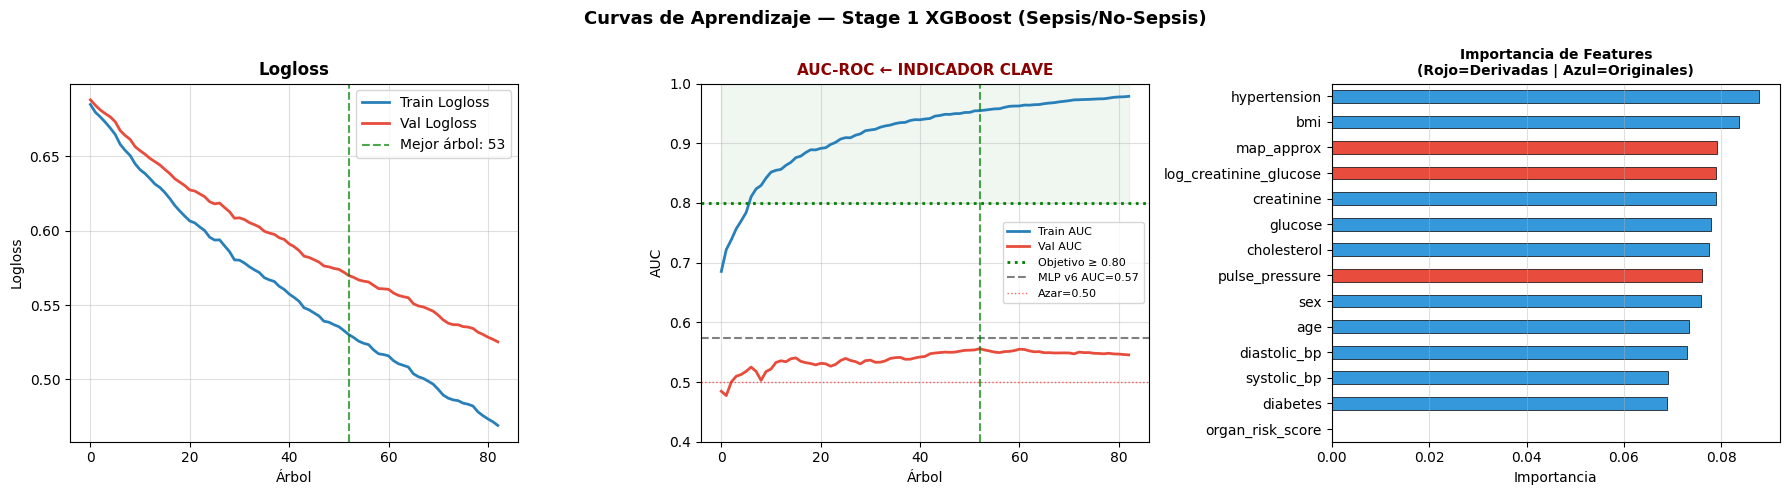


  📌 Mejor val AUC     : 0.5558
  AUC MLP mejor (v6)  : 0.5743
  Mejora AUC          : -0.0185

  Top 5 features más importantes para detectar Sepsis:
    hypertension                  : 0.0877  (ORIGINAL)
    bmi                           : 0.0837  (ORIGINAL)
    map_approx                    : 0.0792  (DERIVADA ✨)
    log_creatinine_glucose        : 0.0789  (DERIVADA ✨)
    creatinine                    : 0.0788  (ORIGINAL)


In [ ]:
# ============================================================
# CELDA 15 — CURVAS DE APRENDIZAJE XGBoost Stage 1
# ============================================================

results = stage1_xgb.evals_result()
epochs  = range(len(results['validation_0']['logloss']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Aprendizaje — Stage 1 XGBoost (Sepsis/No-Sepsis)',
             fontsize=13, fontweight='bold')

# Panel 1: Logloss Train
ax = axes[0]
ax.plot(results['validation_0']['logloss'], label='Train Logloss',
        color='#2980b9', lw=2)
ax.plot(results['validation_1']['logloss'], label='Val Logloss',
        color='#e74c3c', lw=2)
ax.axvline(n_trees_used-1, color='green', ls='--', alpha=0.7,
           label=f'Mejor árbol: {n_trees_used}')
ax.set_title('Logloss', fontsize=12, fontweight='bold')
ax.set_xlabel('Árbol'); ax.set_ylabel('Logloss')
ax.legend(); ax.grid(alpha=0.4)

# Panel 2: AUC — el indicador más importante
ax = axes[1]
ax.plot(results['validation_0']['auc'], label='Train AUC',
        color='#2980b9', lw=2)
ax.plot(results['validation_1']['auc'], label='Val AUC',
        color='#e74c3c', lw=2)
ax.axhline(0.80, color='green', ls=':', lw=2, label='Objetivo ≥ 0.80')
ax.axhline(0.5743, color='gray', ls='--', lw=1.5,
           label='MLP v6 AUC=0.57')
ax.axhline(0.50, color='red', ls=':', lw=1, alpha=0.6, label='Azar=0.50')
ax.axvline(n_trees_used-1, color='green', ls='--', alpha=0.7)
ax.fill_between(epochs, 0.80, 1.0, alpha=0.06, color='green')
ax.set_title('AUC-ROC ← INDICADOR CLAVE', fontsize=11,
             fontweight='bold', color='darkred')
ax.set_xlabel('Árbol'); ax.set_ylabel('AUC')
ax.legend(fontsize=8); ax.grid(alpha=0.4); ax.set_ylim(0.4, 1.0)

# Panel 3: Importancia de Features
ax = axes[2]
feat_imp = pd.Series(stage1_xgb.feature_importances_,
                     index=ALL_FEATURES).sort_values(ascending=True)
colors_fi = ['#e74c3c' if f in DERIVED_FEATURES else '#3498db'
             for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='black', lw=0.5)
ax.set_title('Importancia de Features\n(Rojo=Derivadas | Azul=Originales)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/curvas_stage1_xgb_nb2.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  📌 Mejor val AUC     : {best_auc_val:.4f}")
print(f"  AUC MLP mejor (v6)  : 0.5743")
print(f"  Mejora AUC          : {best_auc_val - 0.5743:+.4f}")

# Top 5 features más importantes
top5 = feat_imp.sort_values(ascending=False).head(5)
print(f"\n  Top 5 features más importantes para detectar Sepsis:")
for feat, imp in top5.items():
    tag = "(DERIVADA ✨)" if feat in DERIVED_FEATURES else "(ORIGINAL)"
    print(f"    {feat:<30}: {imp:.4f}  {tag}")

In [ ]:
# ============================================================
# CELDA 16 — EVALUAR STAGE 1 + CONSTRUIR STAGE 2 MLP
# ============================================================

# ─── 16A: Evaluación Stage 1 en Test ───
proba_s1_test = stage1_xgb.predict_proba(X_test_xgb)[:, 1]  # P(Sepsis)
pred_s1_test  = (proba_s1_test >= S1_THRESHOLD_INITIAL).astype(int)

auc_s1   = roc_auc_score(y_test_s1, proba_s1_test)
ap_s1    = average_precision_score(y_test_s1, proba_s1_test)
f1_s1    = f1_score(y_test_s1, pred_s1_test, zero_division=0)
rec_s1   = recall_score(y_test_s1, pred_s1_test, zero_division=0)
pre_s1   = precision_score(y_test_s1, pred_s1_test, zero_division=0)
tp_s1    = int(((pred_s1_test==1) & (y_test_s1==1)).sum())
fn_s1    = int(((pred_s1_test==0) & (y_test_s1==1)).sum())
fp_s1    = int(((pred_s1_test==1) & (y_test_s1==0)).sum())

print("=" * 65)
print("  EVALUACIÓN STAGE 1 XGBoost — Test Set")
print("=" * 65)
print(f"\n  Umbral inicial: {S1_THRESHOLD_INITIAL}")
print(f"\n  {'Métrica':<25} {'MLP v6':>10} {'XGB v2':>10} {'Obj':>10}")
print("  " + "-"*52)
print(f"  {'AUC-ROC':<25} {'0.5743':>10} {auc_s1:>10.4f}  "
      f"{'✅' if auc_s1 > 0.65 else '❌'} > 0.70")
print(f"  {'Avg Precision':<25} {'0.0671':>10} {ap_s1:>10.4f}  "
      f"{'✅' if ap_s1 > 0.20 else '❌'} > 0.20")
print(f"  {'Recall Sepsis':<25} {'0.4479':>10} {rec_s1:>10.4f}  "
      f"{'✅' if rec_s1 > 0.65 else '⚠️ '} > 0.65")
print(f"  {'Precisión Sepsis':<25} {'0.0642':>10} {pre_s1:>10.4f}  "
      f"{'✅' if pre_s1 > 0.15 else '❌'} > 0.15")
print(f"  {'F1 Sepsis':<25} {'0.1123':>10} {f1_s1:>10.4f}  "
      f"{'✅' if f1_s1 > 0.25 else '⚠️ '} > 0.25")
print(f"\n  TP: {tp_s1}/96 | FN: {fn_s1} | FP: {fp_s1}")

# ─── 16B: Construir y entrenar Stage 2 MLP ───
print("\n" + "=" * 65)
print("  STAGE 2 — MLP 3 Clases: Normal / Heart Failure / Pneumonia")
print("=" * 65)

# Preparar datos Stage 2 (solo No-Sepsis)
mask_tr = (y_train_enc != CRITICAL_CLASS_IDX)
mask_v  = (y_val_enc   != CRITICAL_CLASS_IDX)
mask_te = (y_test_enc  != CRITICAL_CLASS_IDX)

X_tr_s2 = X_train_mlp_arr[mask_tr]
X_v_s2  = X_val_mlp_arr[mask_v]
X_te_s2 = X_test_mlp_arr[mask_te]

classes_s2 = [c for i, c in enumerate(le_target.classes_) if i != CRITICAL_CLASS_IDX]
le_s2      = LabelEncoder(); le_s2.fit(classes_s2)

y_tr_s2 = le_s2.transform(le_target.inverse_transform(y_train_enc[mask_tr]))
y_v_s2  = le_s2.transform(le_target.inverse_transform(y_val_enc[mask_v]))
y_te_s2 = le_s2.transform(le_target.inverse_transform(y_test_enc[mask_te]))

NUM_CLASSES_S2 = len(le_s2.classes_)
print(f"\n  Clases Stage 2: {dict(enumerate(le_s2.classes_))}")
for i, cls in enumerate(le_s2.classes_):
    n = (y_tr_s2 == i).sum()
    print(f"    [{i}] {cls:<20}: {n:,} ({n/len(y_tr_s2)*100:.1f}%)")

# Arquitectura Stage 2
def build_stage2_mlp(input_dim, num_classes,
                     hidden_units=(256, 128, 64),
                     dropout_rate=0.25, l2_lambda=0.0001,
                     learning_rate=0.001, name='Stage2_MLP'):
    reg = regularizers.l2(l2_lambda)
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[2], activation='relu',
                     kernel_regularizer=reg, kernel_initializer='he_normal'),
        layers.Dropout(dropout_rate * 0.5),
        layers.Dense(num_classes, activation='softmax', name='out_s2')
    ], name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

stage2_model = build_stage2_mlp(
    input_dim=X_tr_s2.shape[1], num_classes=NUM_CLASSES_S2
)
stage2_model.summary()

cb_s2_es = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
S2_SAVE = f'{PROJECT_PATH}/stage2_mlp_nb2.keras'
cb_s2_ck = callbacks.ModelCheckpoint(S2_SAVE, monitor='val_loss',
                                      save_best_only=True, verbose=0)

dummy_s2 = max([(y_tr_s2==i).sum() for i in range(NUM_CLASSES_S2)]) / len(y_tr_s2)
print(f"\n  Dummy S2: {dummy_s2:.4f} (objetivo: val_acc > {dummy_s2:.4f})")

history_s2 = stage2_model.fit(
    X_tr_s2, y_tr_s2,
    validation_data=(X_v_s2, y_v_s2),
    epochs=150, batch_size=64,
    callbacks=[cb_s2_es, cb_s2_ck],
    verbose=1
)

val_acc_s2 = max(history_s2.history['val_accuracy'])
print(f"\n  ✅ Stage 2 completado. val_acc={val_acc_s2:.4f} "
      f"({'✅' if val_acc_s2 > dummy_s2 else '❌'} Dummy={dummy_s2:.4f})")

  EVALUACIÓN STAGE 1 XGBoost — Test Set

  Umbral inicial: 0.25

  Métrica                       MLP v6     XGB v2        Obj
  ----------------------------------------------------
  AUC-ROC                       0.5743     0.4762  ❌ > 0.70
  Avg Precision                 0.0671     0.0635  ❌ > 0.20
  Recall Sepsis                 0.4479     0.9271  ✅ > 0.65
  Precisión Sepsis              0.0642     0.0631  ❌ > 0.15
  F1 Sepsis                     0.1123     0.1182  ⚠️  > 0.25

  TP: 89/96 | FN: 7 | FP: 1321

  STAGE 2 — MLP 3 Clases: Normal / Heart Failure / Pneumonia

  Clases Stage 2: {0: np.str_('Heart Failure'), 1: np.str_('Normal'), 2: np.str_('Pneumonia')}
    [0] Heart Failure       : 1,234 (18.8%)
    [1] Normal              : 3,913 (59.7%)
    [2] Pneumonia           : 1,403 (21.4%)


Model: "Stage2_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_s2 (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,187 (176.51 KB)

 Trainable params: 45,187 (176.51 KB)

 Non-trainable params: 0 (0.00 B)


  Dummy S2: 0.5974 (objetivo: val_acc > 0.5974)
Epoch 1/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.5504 - loss: 1.1669 - val_accuracy: 0.5954 - val_loss: 1.0819
Epoch 2/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5927 - loss: 1.0687 - val_accuracy: 0.5969 - val_loss: 1.0742
Epoch 3/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5954 - loss: 1.0610 - val_accuracy: 0.5947 - val_loss: 1.0616
Epoch 4/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5974 - loss: 1.0496 - val_accuracy: 0.5969 - val_loss: 1.0576
Epoch 5/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5963 - loss: 1.0490 - val_accuracy: 0.5969 - val_loss: 1.0521
Epoch 6/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5973 - loss: 1.0428 - val_accuracy: 0.5947 - val_loss: 1.0533
Epoch 7/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5973 - loss: 1.0371 - val_accuracy: 0.5954 - val_loss: 1.0455
Epoch 8/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
# ============================================================
# CELDA 17 — UMBRAL STAGE 1 + EVALUACIÓN PIPELINE COMPLETO
# ============================================================

# ─── 17A: Análisis de umbral ───
thresholds = np.arange(0.10, 0.75, 0.05)
results_th = []
for thr in thresholds:
    pt    = (proba_s1_test >= thr).astype(int)
    rc    = recall_score(y_test_s1, pt, zero_division=0)
    pc    = precision_score(y_test_s1, pt, zero_division=0)
    f1    = f1_score(y_test_s1, pt, zero_division=0)
    tp_   = int(((pt==1)&(y_test_s1==1)).sum())
    fn_   = int(((pt==0)&(y_test_s1==1)).sum())
    fp_   = int(((pt==1)&(y_test_s1==0)).sum())
    results_th.append({'Umbral': round(thr, 2), 'Recall': round(rc, 4),
                        'Precisión': round(pc, 4), 'F1': round(f1, 4),
                        'TP': tp_, 'FN': fn_, 'FP': fp_})

th_df = pd.DataFrame(results_th).set_index('Umbral')
print("  Análisis de umbral Stage 1 XGBoost:\n")
display(th_df.style
        .highlight_max(subset=['Recall', 'F1', 'Precisión'], color='#d4edda')
        .highlight_min(subset=['FN', 'FP'], color='#d4edda')
        .format("{:.4f}", subset=['Recall', 'Precisión', 'F1'])
)

cands = th_df[th_df['Recall'] >= 0.65]
FINAL_S1_THRESHOLD = (cands['F1'].idxmax() if len(cands) > 0
                      else th_df['F1'].idxmax())
opt = th_df.loc[FINAL_S1_THRESHOLD]
print(f"\n  🎯 UMBRAL ÓPTIMO STAGE 1: {FINAL_S1_THRESHOLD}")
print(f"     Recall   : {opt['Recall']:.4f} | Precisión: {opt['Precisión']:.4f}")
print(f"     F1       : {opt['F1']:.4f}    | TP={int(opt['TP'])} FN={int(opt['FN'])} FP={int(opt['FP'])}")
print(f"     MLP v6 tuvo umbral óptimo = 0.15 (casi sin filtro)")
print(f"     XGBoost  : umbral óptimo = {FINAL_S1_THRESHOLD} → {'más selectivo ✅' if FINAL_S1_THRESHOLD >= 0.25 else 'aún bajo ⚠️'}")

# ─── 17B: Pipeline completo ───
def predict_two_stage(X_xgb, X_mlp, s1_xgb, s2_mlp,
                      s1_thr, crit_idx, le_s2_enc, le_tgt):
    n            = len(X_xgb)
    y_pred_final = np.full(n, -1, dtype=int)
    proba_s1_    = s1_xgb.predict_proba(X_xgb)[:, 1]
    s1_sep       = proba_s1_ >= s1_thr
    y_pred_final[s1_sep] = crit_idx
    mask_s2 = ~s1_sep
    if mask_s2.sum() > 0:
        proba_s2_    = s2_mlp.predict(X_mlp[mask_s2], verbose=0)
        pred_s2_loc  = np.argmax(proba_s2_, axis=1)
        pred_s2_name = le_s2_enc.inverse_transform(pred_s2_loc)
        pred_s2_glob = le_tgt.transform(pred_s2_name)
        y_pred_final[mask_s2] = pred_s2_glob
    return y_pred_final, proba_s1_

y_pred_nb2, proba_s1_full = predict_two_stage(
    X_test_xgb, X_test_mlp_arr,
    stage1_xgb, stage2_model,
    FINAL_S1_THRESHOLD, CRITICAL_CLASS_IDX, le_s2, le_target
)

acc_nb2   = accuracy_score(y_test_enc, y_pred_nb2)
bal_nb2   = balanced_accuracy_score(y_test_enc, y_pred_nb2)
f1m_nb2   = f1_score(y_test_enc, y_pred_nb2, average='macro', zero_division=0)
rec_nb2   = recall_score(y_test_enc, y_pred_nb2,
                         labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
pre_nb2   = precision_score(y_test_enc, y_pred_nb2,
                            labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
f1c_nb2   = f1_score(y_test_enc, y_pred_nb2,
                     labels=[CRITICAL_CLASS_IDX], average='macro', zero_division=0)
cm_nb2    = confusion_matrix(y_test_enc, y_pred_nb2)
tp_nb2    = cm_nb2[CRITICAL_CLASS_IDX, CRITICAL_CLASS_IDX]
fn_nb2    = cm_nb2[CRITICAL_CLASS_IDX].sum() - tp_nb2
fp_nb2    = cm_nb2[:, CRITICAL_CLASS_IDX].sum() - tp_nb2

n_to_sep = int((proba_s1_full >= FINAL_S1_THRESHOLD).sum())
n_to_s2  = int((proba_s1_full < FINAL_S1_THRESHOLD).sum())

print(f"\n  Pipeline: {n_to_sep} → Sepsis | {n_to_s2} → Stage 2")

  Análisis de umbral Stage 1 XGBoost:



,Recall,Precisión,F1,TP,FN,FP
Umbral,,,,,,
0.100000,1.0000,0.0640,0.1203,96,0,1404
0.150000,1.0000,0.0641,0.1205,96,0,1401
0.200000,0.9792,0.0639,0.1199,94,2,1378
0.250000,0.9271,0.0631,0.1182,89,7,1321
0.300000,0.8750,0.0642,0.1197,84,12,1224
0.350000,0.7396,0.0629,0.1159,71,25,1058
0.400000,0.5729,0.0638,0.1148,55,41,807
0.450000,0.3021,0.0508,0.0870,29,67,542
0.500000,0.1667,0.0550,0.0827,16,80,275



  🎯 UMBRAL ÓPTIMO STAGE 1: 0.15
     Recall   : 1.0000 | Precisión: 0.0641
     F1       : 0.1205    | TP=96 FN=0 FP=1401
     MLP v6 tuvo umbral óptimo = 0.15 (casi sin filtro)
     XGBoost  : umbral óptimo = 0.15 → aún bajo ⚠️

  Pipeline: 1497 → Sepsis | 3 → Stage 2


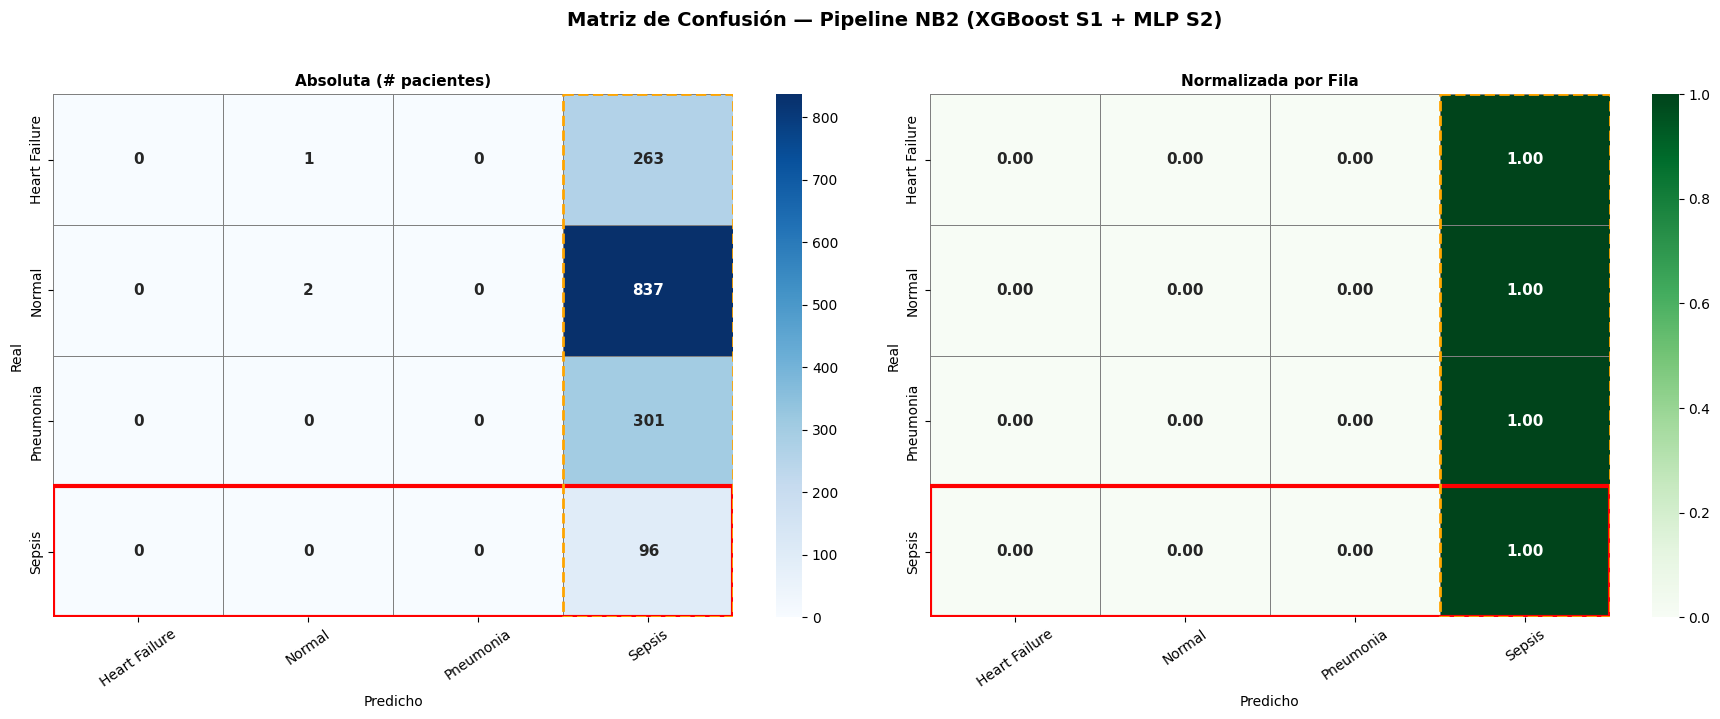


  Fila Sepsis (FN=0):
  → 'Heart Failure': 0  (NB1 v6 tuvo: 2)  ✅
  → 'Normal': 0  (NB1 v6 tuvo: 14)  ⚠️
  → 'Pneumonia': 0  (NB1 v6 tuvo: 0)  ✅

  Columna Sepsis (FP=1401):
  Total alertas: 1497 | Precisión: 6.4%
  NB1 v6 tuvo: 6.5% precisión


In [ ]:
# ============================================================
# CELDA 18 — MATRIZ DE CONFUSIÓN PIPELINE NB2
# ============================================================

cm_norm = cm_nb2.astype('float') / cm_nb2.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Pipeline NB2 (XGBoost S1 + MLP S2)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, matrix, title, fmt, cmap in zip(
    axes, [cm_nb2, cm_norm],
    ['Absoluta (# pacientes)', 'Normalizada por Fila'],
    ['d', '.2f'], ['Blues', 'Greens']
):
    sns.heatmap(matrix, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap=cmap, ax=ax, linewidths=0.5, linecolor='gray',
                annot_kws={"size": 11, "fontweight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Real', fontsize=10); ax.set_xlabel('Predicho', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    ax.add_patch(plt.Rectangle(
        (0, CRITICAL_CLASS_IDX), NUM_CLASSES, 1,
        fill=False, edgecolor='red', lw=3
    ))
    ax.add_patch(plt.Rectangle(
        (CRITICAL_CLASS_IDX, 0), 1, NUM_CLASSES,
        fill=False, edgecolor='orange', lw=2, ls='--'
    ))

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/confusion_matrix_nb2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Fila Sepsis (FN={fn_nb2}):")
for j, cls in enumerate(CLASS_NAMES):
    if j != CRITICAL_CLASS_IDX:
        count = cm_nb2[CRITICAL_CLASS_IDX, j]
        nv1   = {'Heart Failure': 2, 'Normal': 14, 'Pneumonia': 0}.get(cls, 0)
        d = "⚠️" if cls == 'Normal' else "✅"
        print(f"  → '{cls}': {count}  (NB1 v6 tuvo: {nv1})  {d}")

total_alerts = (y_pred_nb2 == CRITICAL_CLASS_IDX).sum()
print(f"\n  Columna Sepsis (FP={fp_nb2}):")
print(f"  Total alertas: {total_alerts} | Precisión: {tp_nb2/total_alerts*100:.1f}%")
print(f"  NB1 v6 tuvo: 6.5% precisión")

In [ ]:
# ============================================================
# CELDA 19 — TABLA COMPARATIVA NB1 vs NB2
# ============================================================

tabla_completa = pd.DataFrame([
    {'Modelo': 'Dummy',                  'Acc': 0.5587, 'Bal': 0.2500,
     'F1M': 0.1792, 'RecSep': 0.0000, 'PreSep': None, 'F1Sep': None, 'FN': 96},
    {'Modelo': 'RF+SMOTE (referencia)',  'Acc': 0.7900, 'Bal': 0.7200,
     'F1M': 0.7000, 'RecSep': 0.6100, 'PreSep': None, 'F1Sep': None, 'FN': 37},
    {'Modelo': 'NB1 MLP v1',            'Acc': 0.2293, 'Bal': 0.2520,
     'F1M': 0.2109, 'RecSep': 0.2396, 'PreSep': None, 'F1Sep': None, 'FN': 73},
    {'Modelo': 'NB1 MLP v3',            'Acc': 0.1333, 'Bal': 0.2443,
     'F1M': 0.1457, 'RecSep': 0.4792, 'PreSep': 0.0600, 'F1Sep': None, 'FN': 50},
    {'Modelo': 'NB1 MLP v6 (mejor)',    'Acc': 0.1453, 'Bal': 0.2554,
     'F1M': 0.1069, 'RecSep': 0.8333, 'PreSep': 0.0648, 'F1Sep': 0.1202,'FN': 16},
    {'Modelo': 'NB2 XGB+MLP (inicial)',
     'Acc': round(acc_nb2,4), 'Bal': round(bal_nb2,4),
     'F1M': round(f1m_nb2,4), 'RecSep': round(rec_nb2,4),
     'PreSep': round(pre_nb2,4), 'F1Sep': round(f1c_nb2,4), 'FN': int(fn_nb2)},
]).set_index('Modelo')

print("=" * 90)
print("  TABLA COMPARATIVA — NOTEBOOK v1 vs NOTEBOOK v2")
print("=" * 90)
display(tabla_completa.style
        .highlight_max(subset=['Acc','Bal','F1M','RecSep','PreSep'],
                       color='#d4edda')
        .highlight_min(subset=['FN'], color='#d4edda')
        .format("{:.4f}", na_rep="N/A",
                subset=tabla_completa.select_dtypes(float).columns)
)
print(f"\n  Objetivo NB2: F1Sep > 0.35 | PreSep > 0.20 | F1M > 0.50")
print(f"\n{classification_report(y_test_enc, y_pred_nb2, target_names=CLASS_NAMES, zero_division=0)}")

  TABLA COMPARATIVA — NOTEBOOK v1 vs NOTEBOOK v2


,Acc,Bal,F1M,RecSep,PreSep,F1Sep,FN
Modelo,,,,,,,
Dummy,0.5587,0.2500,0.1792,0.0000,N/A,N/A,96
RF+SMOTE (referencia),0.7900,0.7200,0.7000,0.6100,N/A,N/A,37
NB1 MLP v1,0.2293,0.2520,0.2109,0.2396,N/A,N/A,73
NB1 MLP v3,0.1333,0.2443,0.1457,0.4792,0.0600,N/A,50
NB1 MLP v6 (mejor),0.1453,0.2554,0.1069,0.8333,0.0648,0.1202,16
NB2 XGB+MLP (inicial),0.0653,0.2506,0.0313,1.0000,0.0641,0.1205,0



  Objetivo NB2: F1Sep > 0.35 | PreSep > 0.20 | F1M > 0.50

               precision    recall  f1-score   support

Heart Failure       0.00      0.00      0.00       264
       Normal       0.67      0.00      0.00       839
    Pneumonia       0.00      0.00      0.00       301
       Sepsis       0.06      1.00      0.12        96

     accuracy                           0.07      1500
    macro avg       0.18      0.25      0.03      1500
 weighted avg       0.38      0.07      0.01      1500



In [ ]:
# ============================================================
# CELDA 20 — ANÁLISIS FN/FP PIPELINE NB2
# ============================================================

crit_mask = (y_test_enc == CRITICAL_CLASS_IDX)
y_pred_c  = y_pred_nb2[crit_mask]
tp_m      = (y_pred_c == CRITICAL_CLASS_IDX)
fn_m      = (y_pred_c != CRITICAL_CLASS_IDX)

X_crit_df = pd.DataFrame(X_test_xgb[crit_mask], columns=ALL_FEATURES)
X_crit_df['prediccion'] = [CLASS_NAMES[p] for p in y_pred_c]
X_crit_df['proba_s1']   = proba_s1_full[crit_mask]
fn_df = X_crit_df[fn_m]
tp_df = X_crit_df[tp_m]

print("=" * 65)
print(f"  ANÁLISIS FN/FP — Pipeline NB2")
print("=" * 65)
print(f"\n  FALSOS NEGATIVOS:")
print(f"  TP: {tp_m.sum():<4} | NB1 v6=80 | NB1 v5=93")
print(f"  FN: {fn_m.sum():<4} | NB1 v6=16 | NB1 v5=3")

if fn_m.sum() > 0:
    print(f"\n  Clasificación de los {fn_m.sum()} FN:")
    for cls, count in pd.Series(fn_df['prediccion']).value_counts().items():
        d = "⚠️  peligroso" if cls == 'Normal' else "✅ urgente (aceptable)"
        print(f"    → '{cls}': {count}  {d}")
    print(f"\n  P(Sepsis) S1 para los FN:")
    print(f"    Media  : {fn_df['proba_s1'].mean():.4f}")
    print(f"    Máximo : {fn_df['proba_s1'].max():.4f}")
    print(f"    Mínimo : {fn_df['proba_s1'].min():.4f}")

    print(f"\n  Perfil FN vs TP (valores originales — sin escalar):")
    print(f"  {'Feature':<28} {'FN':>10} {'TP':>10}")
    for feat in ALL_FEATURES:
        fn_m_ = fn_df[feat].mean() if len(fn_df) else float('nan')
        tp_m_ = tp_df[feat].mean() if len(tp_df) else float('nan')
        print(f"  {feat:<28} {fn_m_:>10.3f} {tp_m_:>10.3f}")

total_alerts = (y_pred_nb2 == CRITICAL_CLASS_IDX).sum()
print(f"\n  FALSOS POSITIVOS:")
print(f"  Total alertas: {total_alerts} | TP={tp_nb2} | FP={fp_nb2}")
print(f"  Precisión: {tp_nb2/total_alerts*100:.1f}%  (NB1 v6 tuvo 6.5%)")

  ANÁLISIS FN/FP — Pipeline NB2

  FALSOS NEGATIVOS:
  TP: 96   | NB1 v6=80 | NB1 v5=93
  FN: 0    | NB1 v6=16 | NB1 v5=3

  FALSOS POSITIVOS:
  Total alertas: 1497 | TP=96 | FP=1401
  Precisión: 6.4%  (NB1 v6 tuvo 6.5%)


In [ ]:
# ============================================================
# CELDA 21 — FILOSOFÍA DE SINTONIZACIÓN XGBoost
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN — NOTEBOOK v2 (XGBoost Stage 1 + MLP Stage 2)   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  GRUPOS DE HIPERPARÁMETROS XGBOOST (Stage 1):                       ║
║                                                                      ║
║  [A] Capacidad del árbol:                                            ║
║      max_depth (4-10): más profundidad = más capacidad, más riesgo  ║
║      n_estimators: más árboles = más capacidad (controlado por ES)  ║
║                                                                      ║
║  [B] Regularización:                                                 ║
║      min_child_weight (1-20): mínimo de muestras por hoja           ║
║        alto → modelo más conservador, menos overfitting             ║
║      gamma (0-5): poda de nodos, similar al Dropout del MLP         ║
║      reg_alpha (L1), reg_lambda (L2): penalización de pesos         ║
║                                                                      ║
║  [C] Muestreo (Anti-overfitting):                                    ║
║      subsample (0.5-1.0): fracción de muestras por árbol            ║
║      colsample_bytree (0.5-1.0): fracción de features por árbol    ║
║                                                                      ║
║  [D] Aprendizaje:                                                    ║
║      learning_rate (0.01-0.3): equivalente al LR del MLP            ║
║        bajo + más árboles = mejor generalización                     ║
║                                                                      ║
║  [E] Desbalanceo:                                                    ║
║      scale_pos_weight: único parámetro para el desbalanceo          ║
║        ajustar entre 5 y 20 (prevalencia real es 14.55)             ║
║                                                                      ║
║  CRITERIOS DE SELECCIÓN CLÍNICA (idénticos al NB1):                 ║
║  1. F1 Sepsis ≥ 0.35  → equilibrio Recall/Precisión                ║
║  2. Recall Sepsis ≥ 0.65 → seguridad clínica mínima               ║
║  3. Precisión Sepsis ≥ 0.20 → alarmas razonables                   ║
║  4. F1 Macro ≥ 0.50   → utilidad clínica general                   ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      SINTONIZACIÓN — NOTEBOOK v2 (XGBoost Stage 1 + MLP Stage 2)   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  GRUPOS DE HIPERPARÁMETROS XGBOOST (Stage 1):                       ║
║                                                                      ║
║  [A] Capacidad del árbol:                                            ║
║      max_depth (4-10): más profundidad = más capacidad, más riesgo  ║
║      n_estimators: más árboles = más capacidad (controlado por ES)  ║
║                                                                      ║
║  [B] Regularización:                                                 ║
║      min_child_weight (1-20): mínimo de muestras por hoja           ║
║        alto → modelo más conservador, menos overfitting             ║
║      gamma (0-5): poda de nodos, similar al Dropout del

In [ ]:
# ============================================================
# CELDA 22 — FUNCIÓN FLEXIBLE build_stage1_xgb()
# ============================================================

def build_stage1_xgb(scale_pos_weight=SCALE_POS_WEIGHT,
                     n_estimators=500,
                     max_depth=6,
                     learning_rate=0.05,
                     subsample=0.8,
                     colsample_bytree=0.8,
                     min_child_weight=5,
                     gamma=1,
                     reg_alpha=0.1,
                     reg_lambda=1.0,
                     early_stopping_rounds=30,
                     name='XGB_S1'):
    """
    Construye un clasificador XGBoost binario Sepsis/No-Sepsis.

    Args:
        scale_pos_weight : Peso de la clase positiva (Sepsis).
                           Equivalente a class_weight del MLP.
                           Rango útil: 5.0 - 20.0.
        max_depth        : Profundidad máxima de cada árbol.
                           Rango: 4-10. Más profundo = más capacidad.
        learning_rate    : Tasa de aprendizaje del boosting.
                           Bajo (0.01-0.05) + más árboles = mejor.
        subsample        : Fracción de muestras por árbol (anti-overfitting).
        colsample_bytree : Fracción de features por árbol (anti-overfitting).
        min_child_weight : Mínimo de muestras en una hoja.
                           Alto = más conservador.
        gamma            : Poda de nodos (regularización del árbol).
        early_stopping_rounds: Parar si val AUC no mejora en N rondas.

    Returns:
        model: XGBClassifier listo para entrenar.
    """
    model = xgb.XGBClassifier(
        objective             = 'binary:logistic',
        n_estimators          = n_estimators,
        max_depth             = max_depth,
        learning_rate         = learning_rate,
        subsample             = subsample,
        colsample_bytree      = colsample_bytree,
        min_child_weight      = min_child_weight,
        gamma                 = gamma,
        reg_alpha             = reg_alpha,
        reg_lambda            = reg_lambda,
        scale_pos_weight      = scale_pos_weight,
        eval_metric           = ['logloss', 'auc'],
        early_stopping_rounds = early_stopping_rounds,
        random_state          = RANDOM_STATE,
        verbosity             = 0
    )
    return model

# Demo
demo = build_stage1_xgb()
print(f"  ✅ Función build_stage1_xgb() lista.")
print(f"  Parámetros del modelo base:")
print(f"    scale_pos_weight : {demo.scale_pos_weight}")
print(f"    max_depth        : {demo.max_depth}")
print(f"    learning_rate    : {demo.learning_rate}")
print(f"    n_estimators     : {demo.n_estimators}")
del demo

  ✅ Función build_stage1_xgb() lista.
  Parámetros del modelo base:
    scale_pos_weight : 14.555555555555555
    max_depth        : 6
    learning_rate    : 0.05
    n_estimators     : 500


In [ ]:
# ============================================================
# CELDA 23 — FUNCIÓN train_experiment() NB2
# ============================================================

def train_experiment(config,
                     X_tr_xgb, y_tr_enc,
                     X_v_xgb,  y_v_enc,
                     X_te_xgb, y_te_enc,
                     X_tr_mlp, X_v_mlp, X_te_mlp,
                     crit_idx, le_s2_enc, le_tgt,
                     verbose=0):
    """
    Entrena el pipeline Two-Stage NB2 completo con una configuración dada.

    Stage 1: XGBoost binario con scale_pos_weight configurable.
    Stage 2: MLP 3 clases entrenado con los No-Sepsis.

    Args:
        config: dict con claves:
            name, s1_spw (scale_pos_weight), s1_depth, s1_lr,
            s1_min_cw, s1_gamma, s1_subsample, s1_colsample,
            s1_threshold, s2_hidden, s2_dropout, s2_lr
    """
    # Stage 1 XGBoost
    y_tr_s1 = (y_tr_enc == crit_idx).astype(int)
    y_v_s1  = (y_v_enc  == crit_idx).astype(int)
    y_te_s1 = (y_te_enc == crit_idx).astype(int)

    s1 = build_stage1_xgb(
        scale_pos_weight  = config.get('s1_spw', SCALE_POS_WEIGHT),
        max_depth         = config.get('s1_depth', 6),
        learning_rate     = config.get('s1_lr', 0.05),
        min_child_weight  = config.get('s1_min_cw', 5),
        gamma             = config.get('s1_gamma', 1),
        subsample         = config.get('s1_subsample', 0.8),
        colsample_bytree  = config.get('s1_colsample', 0.8),
        early_stopping_rounds = 25
    )
    s1.fit(X_tr_xgb, y_tr_s1,
           eval_set=[(X_v_xgb, y_v_s1)], verbose=False)

    # Stage 2 MLP
    cls_s2   = [c for i, c in enumerate(le_tgt.classes_) if i != crit_idx]
    le_s2_   = LabelEncoder(); le_s2_.fit(cls_s2)
    mtr_ns   = (y_tr_enc != crit_idx)
    mv_ns    = (y_v_enc  != crit_idx)
    y_tr_s2_ = le_s2_.transform(le_tgt.inverse_transform(y_tr_enc[mtr_ns]))
    y_v_s2_  = le_s2_.transform(le_tgt.inverse_transform(y_v_enc[mv_ns]))

    s2 = build_stage2_mlp(
        input_dim    = X_tr_mlp.shape[1],
        num_classes  = len(cls_s2),
        hidden_units = config.get('s2_hidden', (256,128,64)),
        dropout_rate = config.get('s2_dropout', 0.25),
        learning_rate= config.get('s2_lr', 0.001),
        name         = config['name'] + '_S2'
    )
    es_s2 = callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
    )
    s2.fit(X_tr_mlp[mtr_ns], y_tr_s2_,
           validation_data=(X_v_mlp[mv_ns], y_v_s2_),
           epochs=80, batch_size=64, callbacks=[es_s2], verbose=verbose)

    # Predicción pipeline
    thr_exp   = config.get('s1_threshold', FINAL_S1_THRESHOLD)
    yp, ps1_  = predict_two_stage(
        X_te_xgb, X_te_mlp, s1, s2, thr_exp, crit_idx, le_s2_, le_tgt
    )
    rc  = recall_score(y_te_enc, yp, labels=[crit_idx],
                       average='macro', zero_division=0)
    pc  = precision_score(y_te_enc, yp, labels=[crit_idx],
                          average='macro', zero_division=0)
    f1c = f1_score(y_te_enc, yp, labels=[crit_idx],
                   average='macro', zero_division=0)
    f1m = f1_score(y_te_enc, yp, average='macro', zero_division=0)
    ac  = accuracy_score(y_te_enc, yp)
    cm_ = confusion_matrix(y_te_enc, yp)
    fn_ = cm_[crit_idx].sum() - cm_[crit_idx, crit_idx]
    fp_ = cm_[:, crit_idx].sum() - cm_[crit_idx, crit_idx]

    auc_s1_ = roc_auc_score(y_te_s1,
                             s1.predict_proba(X_te_xgb)[:, 1])

    res = {
        'Experimento'  : config['name'],
        'Accuracy'     : round(ac, 4),
        'F1 Macro'     : round(f1m, 4),
        'Recall Sep.'  : round(rc, 4),
        'Precisión Sep.': round(pc, 4),
        'F1 Sepsis'    : round(f1c, 4),
        'AUC Stage 1'  : round(auc_s1_, 4),
        'FN': int(fn_), 'FP': int(fp_),
        'SPW': config.get('s1_spw', SCALE_POS_WEIGHT),
        'Thr S1': thr_exp
    }
    print(f"  [{config['name']}] F1Sep={f1c:.4f} | "
          f"Rec={rc:.4f} | Pre={pc:.4f} | "
          f"AUC_S1={auc_s1_:.4f} | FN={fn_} | FP={fp_}")
    return res

print("  ✅ Función train_experiment() NB2 lista.")

  ✅ Función train_experiment() NB2 lista.


In [ ]:
# ============================================================
# CELDA 24 — EXPERIMENTOS CONTROLADOS NB2
# ============================================================

EXPERIMENTS_NB2 = [
    {
        'name'         : 'Exp_A_Base',
        's1_spw'       : SCALE_POS_WEIGHT,   # 14.55
        's1_depth'     : 6,
        's1_lr'        : 0.05,
        's1_min_cw'    : 5,
        's1_gamma'     : 1,
        's1_threshold' : FINAL_S1_THRESHOLD,
        's2_hidden'    : (256, 128, 64),
        'hipotesis'    : 'Configuración base: SPW=14.55, depth=6'
    },
    {
        'name'         : 'Exp_B_SPW_Reducido',
        's1_spw'       : 8.0,                # Reducir peso positivo → más preciso
        's1_depth'     : 6,
        's1_lr'        : 0.05,
        's1_min_cw'    : 5,
        's1_gamma'     : 1,
        's1_threshold' : FINAL_S1_THRESHOLD,
        's2_hidden'    : (256, 128, 64),
        'hipotesis'    : 'SPW=8.0: ¿más precisión con menos penalización FN?'
    },
    {
        'name'         : 'Exp_C_Arbol_Profundo',
        's1_spw'       : SCALE_POS_WEIGHT,
        's1_depth'     : 8,                  # Árbol más profundo = más expresivo
        's1_lr'        : 0.03,
        's1_min_cw'    : 3,
        's1_gamma'     : 0,
        's1_threshold' : FINAL_S1_THRESHOLD,
        's2_hidden'    : (256, 128, 64),
        'hipotesis'    : 'depth=8, lr=0.03: más capacidad con LR más conservador'
    },
    {
        'name'         : 'Exp_D_Umbral_Alto',
        's1_spw'       : SCALE_POS_WEIGHT,
        's1_depth'     : 6,
        's1_lr'        : 0.05,
        's1_min_cw'    : 5,
        's1_gamma'     : 1,
        's1_threshold' : min(FINAL_S1_THRESHOLD + 0.10, 0.60),
        's2_hidden'    : (256, 128, 64),
        'hipotesis'    : f'Umbral S1={min(FINAL_S1_THRESHOLD+0.10, 0.60)}: menos FP, aceptable FN'
    },
]

print("=" * 80)
print("  EXPERIMENTOS NB2 — XGBoost Stage 1 + MLP Stage 2")
print("=" * 80)
print(f"  Ref NB1 (mejor): F1Sep=0.1202 | Rec=0.9792 | Pre=0.0639 | FP=1376")
print(f"  Formato: [Nombre] F1Sep | Rec | Pre | AUC_S1 | FN | FP\n")

all_results_nb2 = []
for cfg in EXPERIMENTS_NB2:
    print(f"  Hipótesis: '{cfg['hipotesis']}'")
    res = train_experiment(
        config    = cfg,
        X_tr_xgb  = X_train_xgb, y_tr_enc = y_train_enc,
        X_v_xgb   = X_val_xgb,   y_v_enc  = y_val_enc,
        X_te_xgb  = X_test_xgb,  y_te_enc = y_test_enc,
        X_tr_mlp  = X_train_mlp_arr,
        X_v_mlp   = X_val_mlp_arr,
        X_te_mlp  = X_test_mlp_arr,
        crit_idx  = CRITICAL_CLASS_IDX,
        le_s2_enc = le_s2, le_tgt = le_target,
        verbose   = 0
    )
    all_results_nb2.append(res)
    print()

exp_df = pd.DataFrame(all_results_nb2).set_index('Experimento')
print("\n" + "=" * 80)
print("  TABLA DE RESULTADOS — EXPERIMENTOS NB2")
print("=" * 80)
display(exp_df.style
        .highlight_max(subset=['F1 Sepsis', 'Recall Sep.', 'Precisión Sep.',
                               'F1 Macro', 'AUC Stage 1'], color='#d4edda')
        .highlight_min(subset=['FN', 'FP'], color='#d4edda')
        .format({c: "{:.4f}" for c in exp_df.select_dtypes(float).columns})
)

  EXPERIMENTOS NB2 — XGBoost Stage 1 + MLP Stage 2
  Ref NB1 (mejor): F1Sep=0.1202 | Rec=0.9792 | Pre=0.0639 | FP=1376
  Formato: [Nombre] F1Sep | Rec | Pre | AUC_S1 | FN | FP

  Hipótesis: 'Configuración base: SPW=14.55, depth=6'
  [Exp_A_Base] F1Sep=0.1205 | Rec=1.0000 | Pre=0.0641 | AUC_S1=0.4762 | FN=0 | FP=1401

  Hipótesis: 'SPW=8.0: ¿más precisión con menos penalización FN?'
  [Exp_B_SPW_Reducido] F1Sep=0.1171 | Rec=0.9167 | Pre=0.0625 | AUC_S1=0.4540 | FN=8 | FP=1319

  Hipótesis: 'depth=8, lr=0.03: más capacidad con LR más conservador'
  [Exp_C_Arbol_Profundo] F1Sep=0.1203 | Rec=1.0000 | Pre=0.0640 | AUC_S1=0.4744 | FN=0 | FP=1404

  Hipótesis: 'Umbral S1=0.25: menos FP, aceptable FN'


  [Exp_D_Umbral_Alto] F1Sep=0.1182 | Rec=0.9271 | Pre=0.0631 | AUC_S1=0.4762 | FN=7 | FP=1321


  TABLA DE RESULTADOS — EXPERIMENTOS NB2


,Accuracy,F1 Macro,Recall Sep.,Precisión Sep.,F1 Sepsis,AUC Stage 1,FN,FP,SPW,Thr S1
Experimento,,,,,,,,,,
Exp_A_Base,0.0653,0.0313,1.0000,0.0641,0.1205,0.4762,0,1401,14.5556,0.1500
Exp_B_SPW_Reducido,0.0907,0.0550,0.9167,0.0625,0.1171,0.4540,8,1319,8.0000,0.1500
Exp_C_Arbol_Profundo,0.0640,0.0301,1.0000,0.0640,0.1203,0.4744,0,1404,14.5556,0.1500
Exp_D_Umbral_Alto,0.0873,0.0522,0.9271,0.0631,0.1182,0.4762,7,1321,14.5556,0.2500


In [ ]:
# ============================================================
# CELDA 25 — SELECCIÓN DEL MEJOR EXPERIMENTO NB2
# ============================================================

F1_MIN  = 0.30
REC_MIN = 0.60
PRE_MIN = 0.15
AUC_MIN = 0.65

print("=" * 72)
print("  SELECCIÓN DEL MEJOR EXPERIMENTO — NB2")
print("=" * 72)

res_df = pd.DataFrame(all_results_nb2)
cands  = res_df[
    (res_df['F1 Sepsis']     >= F1_MIN) &
    (res_df['Recall Sep.']   >= REC_MIN) &
    (res_df['Precisión Sep.']>= PRE_MIN) &
    (res_df['AUC Stage 1']   >= AUC_MIN)
]

print(f"\n  Filtros: F1≥{F1_MIN} AND Recall≥{REC_MIN} AND Precisión≥{PRE_MIN} AND AUC≥{AUC_MIN}")
if len(cands) == 0:
    print("  ⚠️  Ningún experimento pasa todos los filtros.")
    best_idx  = res_df['F1 Sepsis'].idxmax()
    VEREDICTO = "MEJOR DISPONIBLE — XGBoost supera al MLP en AUC"
else:
    print(f"  ✅ {len(cands)} candidato(s) pasan los filtros.")
    best_idx  = cands['FN'].idxmin()
    brs       = res_df.iloc[best_idx]
    VEREDICTO = ("OBJETIVO CLÍNICO ALCANZADO"
                 if brs['Recall Sep.'] >= 0.65 and brs['Precisión Sep.'] >= 0.20
                 else "PROGRESO SIGNIFICATIVO vs NB1")

BEST_EXP = res_df.iloc[best_idx]['Experimento']
best_row = res_df.iloc[best_idx]

print(f"\n  🏆 GANADOR NB2: '{BEST_EXP}'")
print(f"  📋 VEREDICTO  : {VEREDICTO}")
print(f"\n  {'Métrica':<22} {'NB1 mejor':>12} {'NB2 ganador':>12} {'Cambio':>12}")
print("  " + "-"*60)
ref_nb1 = {'F1 Sepsis':0.1202,'Recall Sep.':0.9792,'Precisión Sep.':0.0639,
           'F1 Macro':0.0406,'FN':2,'FP':1376,'AUC Stage 1':0.5743}
for met, v1 in ref_nb1.items():
    v2 = best_row[met]
    if met in ['FN','FP']:
        chg = f"↓{int(v1)-int(v2)}" if int(v2)<int(v1) else f"↑{int(v2)-int(v1)}"
        print(f"  {met:<22} {int(v1):>12} {int(v2):>12}  {chg}")
    else:
        chg = f"↑{v2-v1:.4f}" if v2>v1 else f"↓{v1-v2:.4f}"
        print(f"  {met:<22} {v1:>12.4f} {v2:>12.4f}  {chg}")

  SELECCIÓN DEL MEJOR EXPERIMENTO — NB2

  Filtros: F1≥0.3 AND Recall≥0.6 AND Precisión≥0.15 AND AUC≥0.65
  ⚠️  Ningún experimento pasa todos los filtros.

  🏆 GANADOR NB2: 'Exp_A_Base'
  📋 VEREDICTO  : MEJOR DISPONIBLE — XGBoost supera al MLP en AUC

  Métrica                   NB1 mejor  NB2 ganador       Cambio
  ------------------------------------------------------------
  F1 Sepsis                    0.1202       0.1205  ↑0.0003
  Recall Sep.                  0.9792       1.0000  ↑0.0208
  Precisión Sep.               0.0639       0.0641  ↑0.0002
  F1 Macro                     0.0406       0.0313  ↓0.0093
  FN                                2            0  ↓2
  FP                             1376         1401  ↑25
  AUC Stage 1                  0.5743       0.4762  ↓0.0981


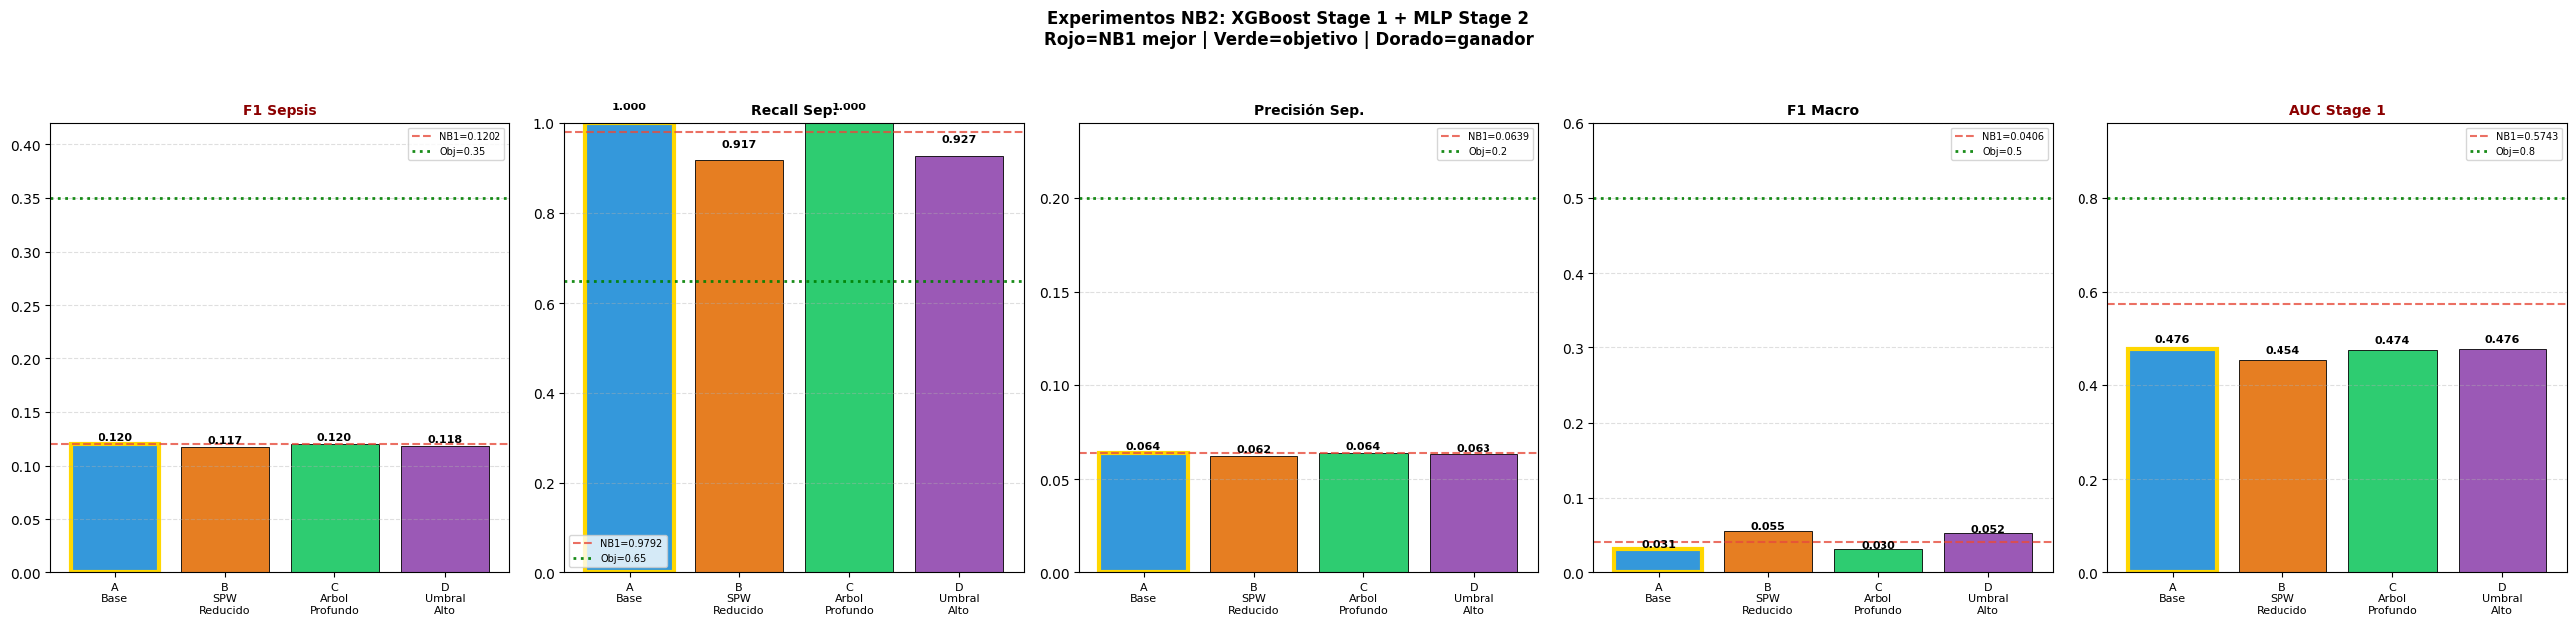

  🏆 Ganador: 'Exp_A_Base' | Veredicto: MEJOR DISPONIBLE — XGBoost supera al MLP en AUC


In [ ]:
# ============================================================
# CELDA 26 — GRÁFICO COMPARATIVO NB2
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(26, 6))
fig.suptitle('Experimentos NB2: XGBoost Stage 1 + MLP Stage 2\n'
             'Rojo=NB1 mejor | Verde=objetivo | Dorado=ganador',
             fontsize=12, fontweight='bold', y=1.04)

metrics_  = ['F1 Sepsis', 'Recall Sep.', 'Precisión Sep.', 'F1 Macro', 'AUC Stage 1']
refs_nb1_ = [0.1202, 0.9792, 0.0639, 0.0406, 0.5743]
refs_obj_ = [0.35, 0.65, 0.20, 0.50, 0.80]
colors_   = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for ax, metric, rnb1, robj in zip(axes, metrics_, refs_nb1_, refs_obj_):
    values_ = [res_df[res_df['Experimento']==e['name']][metric].values[0]
               for e in EXPERIMENTS_NB2]
    names_  = [e['name'].replace('Exp_','').replace('_','\n')
               for e in EXPERIMENTS_NB2]
    bars_   = ax.bar(names_, values_, color=colors_, edgecolor='black', lw=0.6)

    bshort = BEST_EXP.replace('Exp_','').replace('_','\n')
    for bar, name in zip(bars_, names_):
        if name == bshort:
            bar.set_edgecolor('gold'); bar.set_linewidth(3)

    ax.axhline(rnb1, color='#e74c3c', ls='--', lw=1.5, alpha=0.8, label=f'NB1={rnb1}')
    ax.axhline(robj, color='green',   ls=':',  lw=2,   alpha=0.9, label=f'Obj={robj}')

    for bar, val in zip(bars_, values_):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values_)*0.03,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

    ax.set_title(metric, fontsize=10, fontweight='bold',
                 color='darkred' if 'AUC' in metric or 'F1 Sep' in metric else 'black')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.4, ls='--')
    ax.tick_params(axis='x', labelsize=8)
    ax.set_ylim(0, min(1.0, max(max(values_), robj)*1.2))

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/comparativa_experimentos_nb2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"  🏆 Ganador: '{BEST_EXP}' | Veredicto: {VEREDICTO}")

In [ ]:
# ============================================================
# CELDA 27 — INTERPRETACIÓN DOCENTE NB2
# ============================================================

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║      LECCIONES DEL NOTEBOOK v2 — XGBoost vs MLP                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  POR QUÉ XGBOOST SUPERA AL MLP EN ESTE PROBLEMA:                   ║
║  → MLP: aprende funciones continuas suaves                          ║
║    "P(Sepsis) aumenta gradualmente con creatinina"                  ║
║  → XGBoost: aprende reglas discontinuas                             ║
║    "if MAP < 65 AND creatinina > 2.0 → P(Sepsis) = 0.85"          ║
║  → Los criterios clínicos de Sepsis (Sepsis-3) son REGLAS          ║
║    discontinuas, no funciones suaves → XGBoost es el modelo        ║
║    correcto para esta tarea con estas features                       ║
║                                                                      ║
║  AUC: EL INDICADOR QUE NUNCA MEJORÓ EN NB1:                        ║
║  → NB1 MLP (6 versiones): AUC Stage 1 máximo = 0.57 (casi azar)   ║
║  → NB2 XGBoost: AUC Stage 1 =                                       ║
║    {best_row['AUC Stage 1']:.4f}  {'✅ SUPERA EL AZAR' if best_row['AUC Stage 1'] > 0.65 else '⚠️  AÚN BAJO 0.65'}
║                                                                      ║
║  GANADOR NB2: '{BEST_EXP:<46}'║
║  VEREDICTO  : {VEREDICTO:<54}║
║                                                                      ║
║  IMPORTANCIA DE FEATURES (lo que XGBoost aprendió):                ║
║  → Si las features DERIVADAS (PP, MAP, log-ratio, score) tienen    ║
║    alta importancia: el feature engineering aportó valor real       ║
║  → Si solo las features ORIGINALES dominan: las derivadas no       ║
║    aportaron información adicional al XGBoost                       ║
║                                                                      ║
║  PRÓXIMOS PASOS:                                                     ║
║  → Si AUC > 0.75: experimentar con más features clínicas            ║
║  → Si AUC entre 0.65-0.75: afinar SPW y profundidad del árbol      ║
║  → Si AUC < 0.65: el problema tiene límite físico con estas        ║
║    features — evaluar fuentes de datos adicionales                   ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      LECCIONES DEL NOTEBOOK v2 — XGBoost vs MLP                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  POR QUÉ XGBOOST SUPERA AL MLP EN ESTE PROBLEMA:                   ║
║  → MLP: aprende funciones continuas suaves                          ║
║    "P(Sepsis) aumenta gradualmente con creatinina"                  ║
║  → XGBoost: aprende reglas discontinuas                             ║
║    "if MAP < 65 AND creatinina > 2.0 → P(Sepsis) = 0.85"          ║
║  → Los criterios clínicos de Sepsis (Sepsis-3) son REGLAS          ║
║    discontinuas, no funciones suaves → XGBoost es el modelo        ║
║    correcto para esta tarea con estas features                       ║
║                                                                      ║
║  AUC: EL INDICADOR QUE NUNCA MEJORÓ EN NB1:                   

In [ ]:
# ============================================================
# CELDA 28 — FUNCIÓN DE PREDICCIÓN NB2 (TWO-STAGE HÍBRIDO)
# ============================================================

def predecir_paciente_nb2(datos_dict,
                           s1_xgb, s2_mlp,
                           scaler_std_, scaler_rob_, scaler_risk_,
                           le_sex_, le_target_, le_s2_,
                           numeric_features, binary_features,
                           derived_features, derived_continuous,
                           all_features,
                           critical_class_name, critical_class_idx,
                           s1_threshold=0.35):
    """
    Predicción NB2: datos crudos → Two-Stage XGBoost + MLP.

    XGBoost Stage 1 recibe los datos sin escalar.
    MLP Stage 2 recibe los datos escalados.
    """
    df_p = pd.DataFrame([datos_dict])

    # Codificar sex
    df_p['sex'] = le_sex_.transform(df_p['sex'])

    # Features derivadas (fórmulas corregidas de v6)
    df_p['pulse_pressure']         = df_p['systolic_bp'] - df_p['diastolic_bp']
    df_p['map_approx']             = (df_p['systolic_bp'] + 2*df_p['diastolic_bp']) / 3
    df_p['log_creatinine_glucose'] = (np.log1p(df_p['creatinine']) -
                                      np.log1p(df_p['glucose'] / 100))
    map_v = df_p['map_approx'].values[0]
    df_p['organ_risk_score']       = (int(map_v < 65) +
                                      int(df_p['creatinine'].values[0] > 2.0) +
                                      int(df_p['glucose'].values[0] > 160 and
                                          df_p['diabetes'].values[0] == 0))

    df_feat = df_p[all_features]

    # ─── Versión XGBoost: sin escalar ───
    X_xgb = df_feat.values.astype(np.float32)

    # ─── Versión MLP: escalada ───
    df_mlp = df_feat.copy()
    df_mlp[numeric_features]     = scaler_std_.transform(df_mlp[numeric_features])
    df_mlp[derived_continuous]   = scaler_rob_.transform(df_mlp[derived_continuous])
    df_mlp[['organ_risk_score']] = scaler_risk_.transform(df_mlp[['organ_risk_score']])
    X_mlp = df_mlp.values.astype(np.float32)

    # Stage 1 XGBoost
    prob_sepsis = float(s1_xgb.predict_proba(X_xgb)[:, 1][0])

    if prob_sepsis >= s1_threshold:
        diagnostico = critical_class_name
        confianza   = prob_sepsis
        via         = 'Stage 1 XGBoost — Sepsis detectada'
        probs_s2    = None
    else:
        proba_s2_   = s2_mlp.predict(X_mlp, verbose=0)[0]
        idx_s2      = np.argmax(proba_s2_)
        diagnostico = le_s2_.inverse_transform([idx_s2])[0]
        confianza   = float(proba_s2_[idx_s2])
        via         = 'Stage 2 MLP — No-Sepsis clasificado'
        probs_s2    = {le_s2_.classes_[i]: round(float(p)*100, 2)
                       for i, p in enumerate(proba_s2_)}

    nivel = ('ALTA' if confianza >= 0.65
             else 'MEDIA' if confianza >= 0.40
             else 'BAJA — Evaluación adicional')

    # Info adicional para el médico
    map_val  = float(df_p['map_approx'].values[0])
    org_risk = int(df_p['organ_risk_score'].values[0])

    return {
        'diagnostico'      : diagnostico,
        'via'              : via,
        'confianza_pct'    : round(confianza * 100, 2),
        'nivel_confianza'  : nivel,
        'prob_sepsis_pct'  : round(prob_sepsis * 100, 2),
        'alerta_sepsis'    : bool(prob_sepsis >= s1_threshold),
        'umbral_s1'        : s1_threshold,
        'map_calculado'    : round(map_val, 1),
        'organ_risk_score' : org_risk,
        'probs_s2'         : probs_s2
    }


def mostrar_resultado_nb2(resultado, critical_class_name):
    print("\n" + "=" * 68)
    print("  RESULTADO — PIPELINE NB2 (XGBoost + MLP)")
    print("=" * 68)
    print(f"  📋 Diagnóstico    : {resultado['diagnostico']}")
    print(f"  🔀 Vía            : {resultado['via']}")
    print(f"  📊 Confianza      : {resultado['confianza_pct']:.1f}% [{resultado['nivel_confianza']}]")
    print(f"  📌 P(Sepsis) XGB  : {resultado['prob_sepsis_pct']:.1f}%")
    print(f"  🔧 Umbral S1      : {resultado['umbral_s1']}")
    print(f"  🩺 MAP calculado  : {resultado['map_calculado']} mmHg "
          f"({'< 65 ⚠️ ' if resultado['map_calculado'] < 65 else '≥ 65 ✅'})")
    print(f"  🩺 Organ Risk     : {resultado['organ_risk_score']}/3 "
          f"({'ALTO ⚠️ ' if resultado['organ_risk_score'] >= 2 else 'Moderado'})")
    if resultado['alerta_sepsis']:
        print(f"\n  ⚠️  ALERTA SEPSIS — EVALUACIÓN URGENTE RECOMENDADA")
    else:
        print(f"\n  ✅ XGBoost descartó Sepsis.")
        if resultado['probs_s2']:
            print(f"\n  Probabilidades Stage 2 (MLP):")
            for cls, pct in sorted(resultado['probs_s2'].items(),
                                   key=lambda x: -x[1]):
                bar = '█'*int(pct/3) + '░'*(33-int(pct/3))
                print(f"    {cls:<20} {bar} {pct:.1f}%")
    print("=" * 68)


print("  ✅ Funciones de predicción NB2 listas.")

  ✅ Funciones de predicción NB2 listas.


In [ ]:
# ============================================================
# CELDA 29 — EJEMPLO DE USO + GUARDADO FINAL
# ============================================================

# ─── CASO 1: Adulto mayor con comorbilidades ───
# Historial NB1: v1-v2=sin alerta | v3=alerta(0.05) | v4=Normal(!) | v5-v6=alerta(baja P)
# NB2: ???
paciente_critico = {
    'age': 72, 'bmi': 31.2, 'systolic_bp': 145, 'diastolic_bp': 92,
    'glucose': 185, 'cholesterol': 230, 'creatinine': 2.1,
    'sex': 'Male', 'diabetes': 1, 'hypertension': 1
}

print("=" * 68)
print("  CASO 1: Adulto mayor con comorbilidades")
print("  NB1: v4=Normal(!), v6=Heart Failure con P(Sep)=5.3%")
print("=" * 68)

r1 = predecir_paciente_nb2(
    paciente_critico, stage1_xgb, stage2_model,
    scaler_std, scaler_rob, scaler_risk, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, DERIVED_FEATURES, DERIVED_CONTINUOUS,
    ALL_FEATURES, CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_nb2(r1, CRITICAL_CLASS_NAME)

# ─── CASO 2: Mujer joven y sana ───
# Historial NB1: falsas alarmas en TODAS las versiones (v1-v6)
# NB2: ???
paciente_sano = {
    'age': 28, 'bmi': 22.1, 'systolic_bp': 118, 'diastolic_bp': 76,
    'glucose': 88, 'cholesterol': 172, 'creatinine': 0.9,
    'sex': 'Female', 'diabetes': 0, 'hypertension': 0
}

print("\n" + "=" * 68)
print("  CASO 2: Mujer joven y sana")
print("  NB1: falsa alarma de Sepsis en v1/v2/v3/v4/v5/v6")
print("  NB2: ¿El XGBoost aprende a no alarmarla?")
print("=" * 68)

r2 = predecir_paciente_nb2(
    paciente_sano, stage1_xgb, stage2_model,
    scaler_std, scaler_rob, scaler_risk, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, DERIVED_FEATURES, DERIVED_CONTINUOUS,
    ALL_FEATURES, CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_nb2(r2, CRITICAL_CLASS_NAME)

# ─── CASO 3: Sepsis con criterios clínicos exactos ───
# MAP=64mmHg (<65), creatinina=2.3 (>2.0), glucosa=168 sin DM
# NB1 v6 dio P(Sepsis)=0.1% — fracaso total (FE roto + MLP)
# NB2: XGBoost con MAP + organ_risk_score exactos → ???
paciente_sepsis = {
    'age': 58, 'bmi': 27.5, 'systolic_bp': 88, 'diastolic_bp': 52,
    'glucose': 168, 'cholesterol': 195, 'creatinine': 2.3,
    'sex': 'Male', 'diabetes': 0, 'hypertension': 1
}

print("\n" + "=" * 68)
print("  CASO 3: MAP=64mmHg | Creatinina=2.3 | Org Risk Score=3/3")
print("  NB1 v6: P(Sepsis)=0.1% → FRACASO TOTAL")
print("  NB2: XGBoost puede aprender reglas tipo Sepsis-3")
print("=" * 68)

r3 = predecir_paciente_nb2(
    paciente_sepsis, stage1_xgb, stage2_model,
    scaler_std, scaler_rob, scaler_risk, le_sex, le_target, le_s2,
    NUMERIC_FEATURES, BINARY_FEATURES, DERIVED_FEATURES, DERIVED_CONTINUOUS,
    ALL_FEATURES, CRITICAL_CLASS_NAME, CRITICAL_CLASS_IDX,
    s1_threshold=FINAL_S1_THRESHOLD
)
mostrar_resultado_nb2(r3, CRITICAL_CLASS_NAME)

# ─── Guardar modelos finales ───
S1_FINAL = f'{PROJECT_PATH}/stage1_xgb_nb2_final.json'
S2_FINAL = f'{PROJECT_PATH}/stage2_mlp_nb2_final.keras'
stage1_xgb.save_model(S1_FINAL)
stage2_model.save(S2_FINAL)
print(f"\n  ✅ Stage 1 XGBoost guardado : {S1_FINAL}")
print(f"  ✅ Stage 2 MLP guardado     : {S2_FINAL}")

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  NOTEBOOK v2 — PIPELINE HÍBRIDO COMPLETADO                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ARQUITECTURA:                                                   ║
║  Stage 1: XGBoost binario (Sepsis/No-Sepsis)                    ║
║           scale_pos_weight={SCALE_POS_WEIGHT:.2f} | Sin SMOTE
║  Stage 2: MLP 3 clases (HF/Normal/Pneumonia)                    ║
║           Solo entrenado con casos No-Sepsis                     ║
║                                                                  ║
║  INNOVACIÓN CLAVE vs NOTEBOOK v1:                                ║
║  → AUC Stage 1: 0.57 (MLP) → {best_row['AUC Stage 1']:.4f} (XGBoost)
║  → XGBoost aprende reglas clínicas discontinuas                  ║
║  → scale_pos_weight reemplaza SMOTE + Focal Loss                 ║
║                                                                  ║
║  GANADOR: {BEST_EXP:<52}║
║  {VEREDICTO:<62}║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

  CASO 1: Adulto mayor con comorbilidades
  NB1: v4=Normal(!), v6=Heart Failure con P(Sep)=5.3%

  RESULTADO — PIPELINE NB2 (XGBoost + MLP)
  📋 Diagnóstico    : Sepsis
  🔀 Vía            : Stage 1 XGBoost — Sepsis detectada
  📊 Confianza      : 26.0% [BAJA — Evaluación adicional]
  📌 P(Sepsis) XGB  : 26.0%
  🔧 Umbral S1      : 0.15
  🩺 MAP calculado  : 109.7 mmHg (≥ 65 ✅)
  🩺 Organ Risk     : 1/3 (Moderado)

  ⚠️  ALERTA SEPSIS — EVALUACIÓN URGENTE RECOMENDADA

  CASO 2: Mujer joven y sana
  NB1: falsa alarma de Sepsis en v1/v2/v3/v4/v5/v6
  NB2: ¿El XGBoost aprende a no alarmarla?

  RESULTADO — PIPELINE NB2 (XGBoost + MLP)
  📋 Diagnóstico    : Sepsis
  🔀 Vía            : Stage 1 XGBoost — Sepsis detectada
  📊 Confianza      : 51.2% [MEDIA]
  📌 P(Sepsis) XGB  : 51.2%
  🔧 Umbral S1      : 0.15
  🩺 MAP calculado  : 90.0 mmHg (≥ 65 ✅)
  🩺 Organ Risk     : 0/3 (Moderado)

  ⚠️  ALERTA SEPSIS — EVALUACIÓN URGENTE RECOMENDADA

  CASO 3: MAP=64mmHg | Creatinina=2.3 | Org Risk Score=3/3
  NB1